In [2]:
import numpy as np, itertools
import tools21cm as t2c, numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"

from scipy import special
from scipy import stats
from scipy.optimize import curve_fit
from scipy.special import jn
from scipy.special import jv
from scipy.integrate import quad

from tqdm import tqdm

import astropy.units as u
import astropy.constants as cst
from astropy.cosmology import Planck18 as cosmo
from astropy.coordinates import Angle

from matplotlib.colors import LogNorm

In [2]:
def galactic_synch_fg_custom(z, ncells, boxsize, rseed=False):
    """
    Simulated synchrotron emission. Simplified because of removed noise.
    """
    if(isinstance(z, float)):
        z = np.array([z])
    else:
        z = np.array(z, copy=False)

    gf_data = np.zeros((ncells, ncells, z.size))

    if(rseed): 
        np.random.seed(rseed)
	
    X  = np.random.normal(size=(ncells, ncells))
    Y  = np.random.normal(size=(ncells, ncells))
    nu_s,A150,beta_,a_syn,Da_syn = 150,513,2.34,2.8,0.1
	
    for i in range(0, z.size):
        nu = t2c.cosmo.z_to_nu(z[i])
        U_cb  = (np.mgrid[-ncells/2:ncells/2,-ncells/2:ncells/2]+0.5)*t2c.cosmo.z_to_cdist(z[i])/boxsize
        l_cb  = 2*np.pi*np.sqrt(U_cb[0,:,:]**2+U_cb[1,:,:]**2)
        C_syn = A150*(1000/l_cb)**beta_
        solid_angle = boxsize**2/t2c.cosmo.z_to_cdist(z[i])**2
        AA = np.sqrt(solid_angle*C_syn/2)
        T_four = AA*(X+Y*1j)
        T_real = np.abs(np.fft.ifft2(T_four))   #in Jansky
        gf_data[..., i] = t2c.telescope_functions.jansky_2_kelvin(T_real*1e6, z[i], boxsize=boxsize, ncells=ncells)
    
    return gf_data.squeeze(), l_cb

def telescope_beam_pattern(x, y, D=45, z=7):
    """
    Returns a 2D Gaussian array representing the telescope beam pattern.

    Parameters
    ----------
    x : ndarray
        Meshgrid x-coordinates.
    y : ndarray
        Meshgrid y-coordinates.
    D : float, optional
        Telescope dish diameter, in meters (default is 45).
    z : float, optional
        Redshift, which is converted to observation frequency (default is 7).

    Returns
    -------
    ndarray
        A 2D Gaussian array representing the telescope beam pattern.

    Notes
    -----
    The Gaussian array is calculated based on the provided dish diameter and redshift.
    """
    freq= t2c.cosmo.z_to_nu(z) * 10**6
    lam = cst.c.value / freq
    fwhm= 1.03*lam / D
    theta_0 = 0.6* fwhm
    return np.exp(-((x**2 + y**2) / theta_0**2))

def gaussian_source_2d(x, y, cov):
    """
    Calculate the value of a 2D Gaussian source at given coordinates (x, y).

    Parameters:
    - x (float): x-coordinate of the point.
    - y (float): y-coordinate of the point.
    - cov (list): Covariance matrix in arcseconds.

    Returns:
    - float: Value of the 2D Gaussian source at the given coordinates.

    Notes:
    - The covariance matrix takes two values provided in arcseconds.
    - The mean of the Gaussian source is assumed to be (0, 0).
    """
    mean = np.array([0, 0])  # Mean of the Gaussian source
    cov = np.array([[(cov[0] * u.arcsec).to('rad').value, 0], [0, (cov[1] * u.arcsec).to('rad').value]])
    x_diff = x - mean[0]
    y_diff = y - mean[1]
    inv_cov = np.linalg.inv(cov)
    exponent = -0.5 * (x_diff**2 * inv_cov[0, 0] + y_diff**2 * inv_cov[1, 1] + 2 * x_diff * y_diff * inv_cov[0, 1])
    prefactor = 1 / (2 * np.pi * np.sqrt(np.linalg.det(cov)))

    return prefactor * np.exp(exponent)

def hirax_layout(N_ant, range):
    """
    Generates a square grid layout of antennas, similar to HIRAX.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).

    Returns
    -------
    ndarray
        An array containing the coordinates of the antennas arranged in a square grid.
        Each row represents the (x, y) coordinates of an antenna.
    """
    x= np.linspace(range[0], range[1], int(np.sqrt(N_ant)))
    X, Y= np.meshgrid(x, x)
    return np.dstack((X, Y)).reshape(-1, 2)

def random_layout(N_ant, range, seed):
    """
    Generates a random layout of antennas within the specified range.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).
    seed : int
        Seed value for random number generation.

    Returns
    -------
    ndarray
        An array containing the coordinates of the randomly placed antennas.
        Each row represents the (x, y) coordinates of an antenna.
    """

    np.random.seed(seed)
    X= np.random.uniform(range[0], range[1], N_ant)
    Y= np.random.uniform(range[0], range[1], N_ant)

    return np.dstack((X,Y)).reshape(-1, 2)

def median_index(list):
    """
    Returns the index of the median value in a numpy list.

    Parameters:
    - list: numpy array or list
        The input array containing numerical values.

    Returns:
    - int
        The index of the element closest to the median value.

    Raises:
    - ValueError: If the input list is empty.
    """
    average = np.mean(list)
    closest_index = np.abs(list - average).argmin()
    return closest_index

def arbitrary_index(list, value):
    """
    Find the index of the closest element in a list to a given value.

    Parameters:
    list (array-like): The list of values.
    value (float): The value to find the closest index to.

    Returns:
    int: The index of the closest element in the list to the given value.
    """
    closest_index = np.abs(list - value).argmin()
    return closest_index

def visibility_matrix_func(xyz_coord, lmn_coord, redshift, I_sky, beam_pattern):
    """
    Compute the visibility matrix for a given set of antennas and sky image.

    Parameters
    ----------
    xyz_coord : array_like
        Array of x, y, and z coordinates of antennas.
    lmn_coord : array_like
        Array of l, m, and n coordinates representing the direction of the sky image.
    redshift : float
        Redshift observed with 21-cm.
    I_sky : array_like
        Array containing the intensity of the sky image.
    beam_pattern : array_like
        Array representing the beam pattern of the telescope.

    Returns
    -------
    visibility_list : ndarray
        A 1D array of length N_B containing visibility values for each baseline.
    visibility_matrix : ndarray
        A 2D array representing the visibility matrix with shape (N_ant, N_ant).
    """
    N_ant= len(xyz_coord) #Number of antennas
    N_B= int(N_ant*(N_ant-1) / 2) #Number of baselines
    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c.value / freq

    pair_comb= list(itertools.combinations(range(N_ant), 2)) #Get pair of antennas

    baseline_coord= np.empty((N_B, xyz_coord.shape[1])) #Initialize a baseline vectors array
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128) #Initialize a visibility array
    visibility_list= np.empty(N_B, dtype=np.complex128) #Initialize a visibility list

    for i in tqdm(range(N_B)):
        aa, bb= pair_comb[i]

        #Calculate distance between antennas
        uv= ((xyz_coord[bb]- xyz_coord[aa]) / lam)
        baseline_coord[i]= uv

        #Calculate the fringe pattern
        fringe= np.exp(-2j * np.pi * (uv[0] * lmn_coord[:,0] + uv[1] * lmn_coord[:,1]))

        #Reshape fringe_pattern to match the shape of I_sky
        fringe_reshaped = fringe.reshape(I_sky.shape)

        #Calculate visibility for the current baseline
        visibility= np.sum(fringe_reshaped * I_sky * beam_pattern)

        visibility_list[i]= visibility

        #Store the visibility value in the array
        visibility_matrix[aa, bb] = visibility
        visibility_matrix[bb, aa] = np.conj(visibility) #Visibility is symmetric

    return visibility_list, visibility_matrix, baseline_coord

def visibility_rotation_synthesis(lmn_coord, rotated_baselines, I_sky, beam_pattern, N_ant):
    N_B= int(N_ant*(N_ant-1) / 2)

    assert np.shape(rotated_baselines)[0] == N_B

    pair_comb= list(itertools.combinations(range(N_ant), 2)) #Get pair of antennas
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128) #Initialize a visibility array
    visibility_list= np.empty(N_B, dtype=np.complex128) #Initialize a visibility list

    for i in range(N_B):
        aa, bb= pair_comb[i]
        uv= rotated_baselines[i]
        fringe= np.exp(-2j * np.pi * (uv[0] * lmn_coord[:,0] + uv[1] * lmn_coord[:,1]))
        fringe_reshaped = fringe.reshape(I_sky.shape)
        visibility= np.sum(fringe_reshaped * I_sky * beam_pattern)
        visibility_list[i]= visibility

        visibility_matrix[aa, bb]=visibility
        visibility_matrix[bb, aa] = np.conj(visibility)

    return visibility_list, visibility_matrix

def Earth_Rotation_Effect(HA, delta):
    HA, delta = HA.to('rad').value, delta.to('rad').value
    
    return np.array([[np.sin(HA), np.cos(HA)], 
                     [-np.sin(delta)*np.cos(HA), np.sin(delta)*np.sin(HA)]])

def visibility_correlation_func(index, baseline_coord, visibility_list, N_B):
    """
    Computes visibility correlation and baseline distances from a given baseline index.

    Parameters:
    - index: int
        Index of the baseline vector.
    - baseline_coord: numpy.ndarray
        Array containing baseline coordinates.
    - visibility_list: numpy.ndarray
        Array containing visibility values.
    - N_B: int
        Total number of baseline vectors.

    Returns:
    - vis_corr: numpy.ndarray
        Array of visibility correlations.
    - baseline_distances_norm: numpy.ndarray
        Array of normalized baseline distances.
    """
    indices= np.linspace(0, N_B-1, N_B)
    indices_combinations= list(itertools.product([index], range(N_B))) #Generate combinations
    baseline_distances= np.empty((len(indices), 2)) #Create empty array for calculating distance between two vectors
    vis_corr= np.empty(len(indices), dtype=np.complex128)

    for i in range(len(indices)):
        ii, jj = indices_combinations[i]
        vis_corr[i]= visibility_list[ii] * np.conj(visibility_list[jj])
        baseline_distances[i]= baseline_coord[jj] - baseline_coord[ii]

    baseline_distances_norm= np.linalg.norm(baseline_distances, axis=1)

    return vis_corr.real, baseline_distances_norm

def visibility_matrix_func_new_method(xyz_coord, sky_coord, redshift, I_sky, beam_pattern):
    l_coord, m_coord= np.meshgrid(sky_coord, sky_coord)
    N_ant= len(xyz_coord)
    N_B= int(N_ant*(N_ant-1) / 2)
    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c.value / freq
    pair_comb= list(itertools.combinations(range(N_ant), 2))
    baseline_coord= np.empty((N_B, xyz_coord.shape[1]))
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128)
    visibility_list= np.empty(N_B, dtype=np.complex128)

    for i in tqdm(range(N_B)):
        aa, bb= pair_comb[i]
        uv= (xyz_coord[bb]- xyz_coord[aa]) / lam
        baseline_coord[i]= uv
        fringe= np.exp(-2j * np.pi * (uv[0] * l_coord + uv[1] * m_coord))
        vis= np.sum(fringe*I_sky*beam_pattern)
        visibility_list[i]= vis
        visibility_matrix[aa, bb]= vis
        visibility_matrix[bb, aa]= np.conj(vis)
    
    return visibility_list, visibility_matrix, baseline_coord

def image_reconstructing_func(vis_list, baselines, u_min, u_max, bin_len, bin_res):
    """
    Reconstructs an image from visibility data using interferometry.

    Parameters:
    vis_list (array-like): List of visibility values.
    baselines (array-like): List of baseline coordinates.
    u_min (float): Minimum value of the u-coordinate.
    u_max (float): Maximum value of the u-coordinate.
    bin_len (float): Length of the bin.
    bin_res (float): Resolution of the bin.

    Returns:
    array-like: Reconstructed image.
    """
    uv_bin= np.linspace(u_min, u_max, int(bin_len/ bin_res))
    
    uv_plane_binned= stats.binned_statistic_2d(x=baselines[:,0], y=baselines[:,1], values= vis_list,
                                               statistic='sum', bins=[uv_bin, uv_bin]).statistic
    uv_sampl_binned= stats.binned_statistic_2d(x=baselines[:,0], y=baselines[:,1], values= vis_list,
                                               statistic='count', bins=[uv_bin, uv_bin]).statistic
    uv_plane_binned /= np.where(uv_sampl_binned > 0, uv_sampl_binned, 1)

    x= np.fft.fftshift(np.fft.fftfreq(len(uv_bin), np.diff(uv_bin)[0]))

    return uv_plane_binned, uv_bin, uv_sampl_binned, x

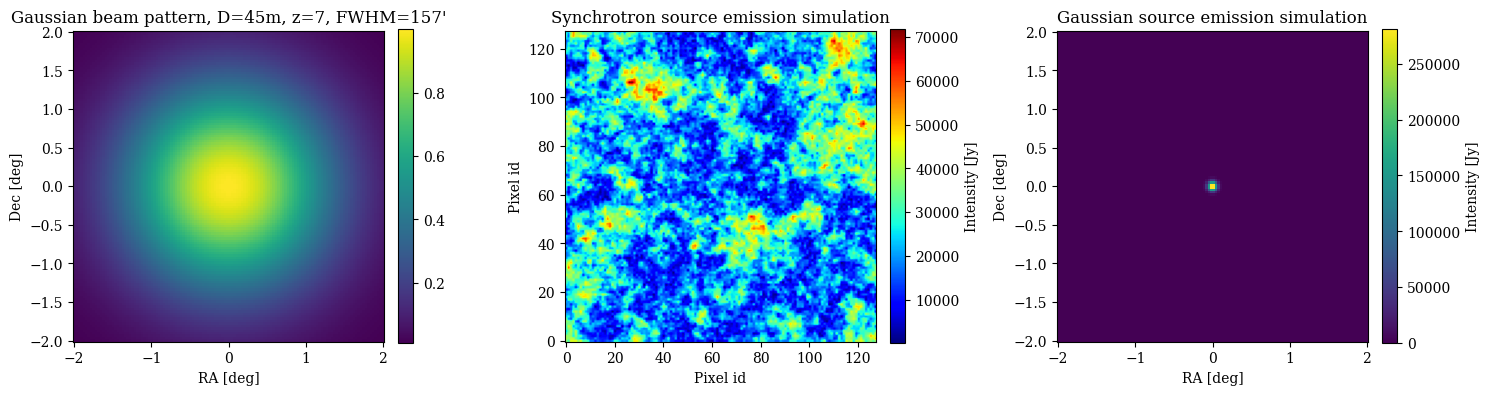

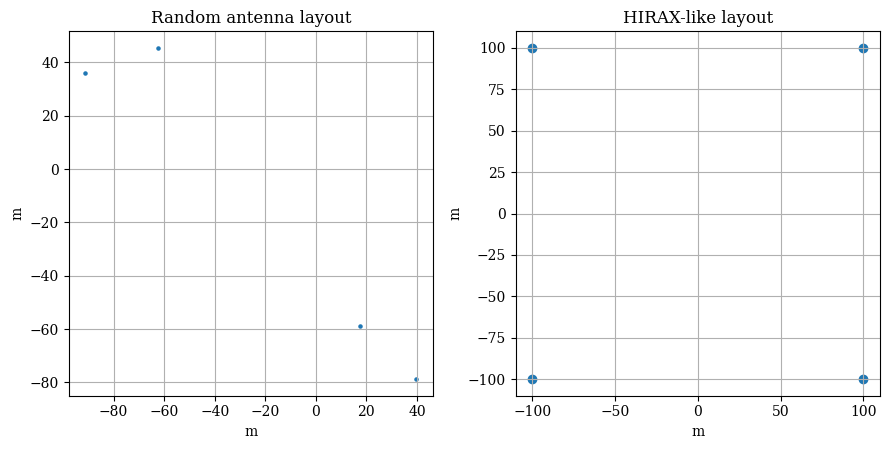

In [12]:
FoV= 4.*u.deg

# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, 128).to('rad').value

# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

#***********************************************
#Generate the coordinates of the telescope layout
xyz_grid= hirax_layout(2**2, [-100., 100.])
xyz_random= random_layout(2**2, [-100, 100], 2024)
#***********************************************

#Angular diameter distance (in Mpc) for a specified redshift and FoV in deg
rshift=8.52
ang_dim_dist= FoV.to('rad').value * cosmo.angular_diameter_distance(rshift).value

#Gaussian and synchrotron sources, beam pattern
gaussian_source= gaussian_source_2d(l_coord, m_coord, [0.1, 0.1])
synchro_source, l= galactic_synch_fg_custom(z=[rshift], ncells=len(thet), boxsize=ang_dim_dist, rseed=2024)
beam_pattern= telescope_beam_pattern(l_coord, m_coord)

#***********************************************
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].pcolormesh(np.rad2deg(l_coord), np.rad2deg(m_coord), beam_pattern, cmap='viridis')
axes[0].set_ylabel('Dec [deg]')
axes[0].set_xlabel('RA [deg]')
axes[0].set_title("Gaussian beam pattern, D=45m, z=7, FWHM=157'")
axes[0].set_box_aspect(1)
plt.colorbar(im0, fraction=0.046, pad=0.04)

im1 = axes[1].imshow(synchro_source, cmap='jet', origin= 'lower')
axes[1].set_title("Synchrotron source emission simulation")
axes[1].set_ylabel('Pixel id')
axes[1].set_xlabel('Pixel id')
axes[1].set_box_aspect(1)
plt.colorbar(im1, label='Intensity [Jy]', fraction=0.046, pad=0.04)

im2 = axes[2].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, gaussian_source, cmap='viridis')
axes[2].set_title('Gaussian source emission simulation')
axes[2].set_ylabel('Dec [deg]')
axes[2].set_xlabel('RA [deg]')
axes[2].set_box_aspect(1)
plt.colorbar(im2, label='Intensity [Jy]', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

#***********************************************
fig, axes= plt.subplots(1, 2, figsize=(9, 7))

axes[0].scatter(xyz_random[:, 0], xyz_random[:, 1], s=5)
axes[0].set_xlabel("m")
axes[0].set_ylabel("m")
axes[0].set_title("Random antenna layout")
axes[0].grid()
axes[0].set_box_aspect(1)

axes[1].scatter(xyz_grid[:,0], xyz_grid[:, 1])
axes[1].set_xlabel("m")
axes[1].set_ylabel("m")
axes[1].set_title("HIRAX-like layout")
axes[1].grid()
axes[1].set_box_aspect(1)

plt.tight_layout()
plt.show()

## __Plotting the fringe pattern using the new method.__

100%|██████████| 6/6 [00:00<00:00, 193.39it/s]


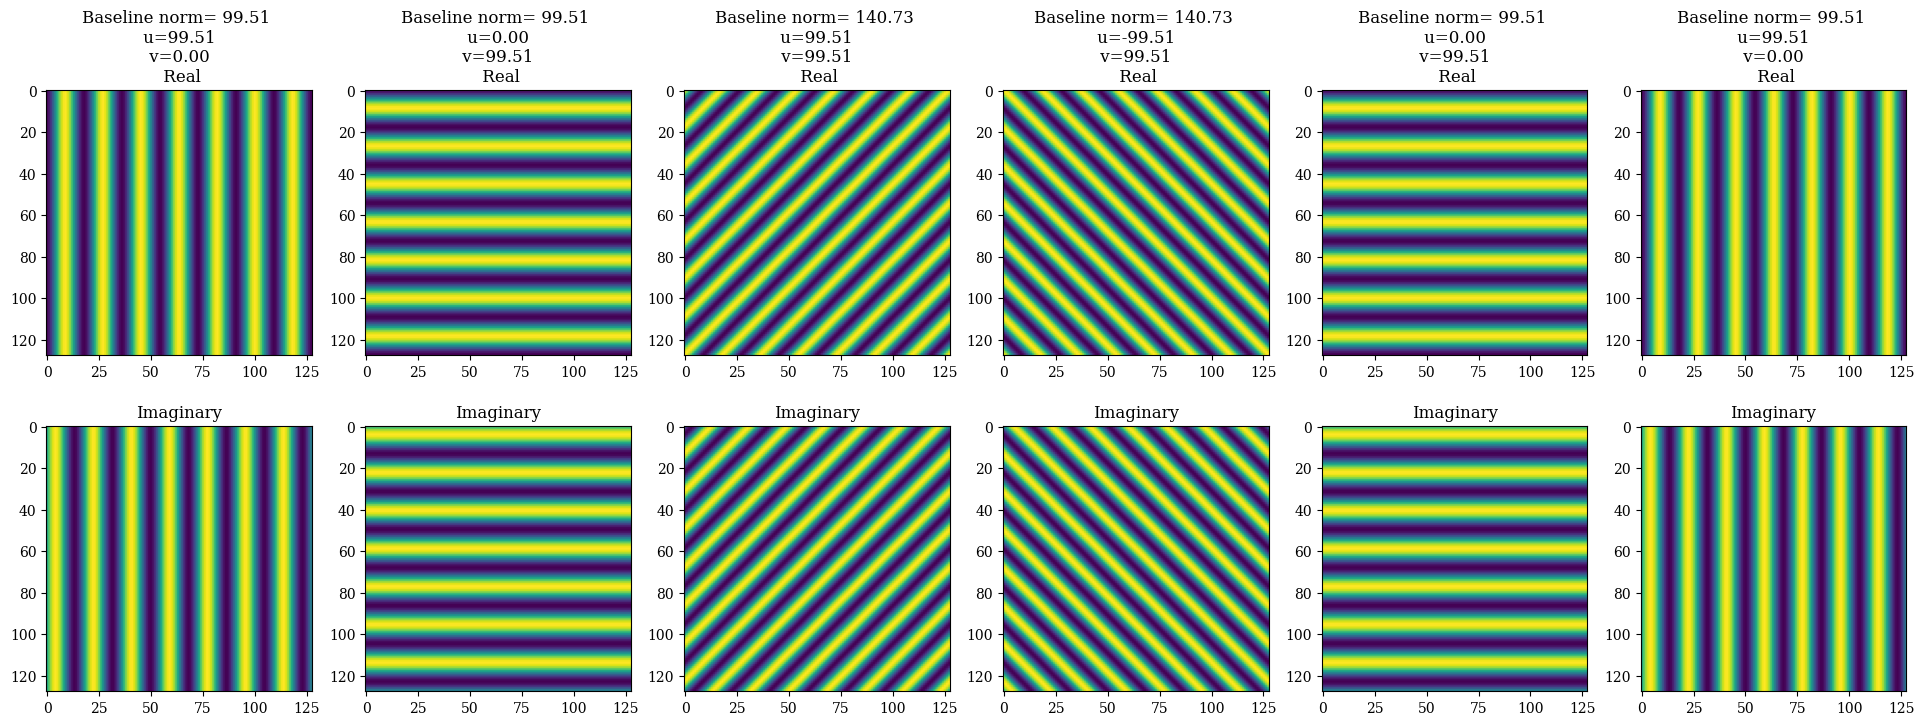

In [13]:
FoV= 4.*u.deg

# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, 128).to('rad').value

# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

xyz_coord= xyz_grid

N_ant= len(xyz_coord)
N_B= int(N_ant*(N_ant-1) / 2)
freq = t2c.cosmo.z_to_nu(rshift) * 10**6
lam = cst.c.value / freq
pair_comb= list(itertools.combinations(range(N_ant), 2))

baseline_coord= np.empty((N_B, xyz_coord.shape[1]))
visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128)
visibility_list= np.empty(N_B, dtype=np.complex128)
fringe_list= []

fig, axes= plt.subplots(2, N_B, figsize=(24, 8))

for i in tqdm(range(N_B)):
    aa, bb= pair_comb[i]

    #Calculate distance between antennas
    uv= ((xyz_coord[bb]- xyz_coord[aa]) / lam)
    baseline_coord[i]= uv
    fringe= np.exp(-2j * np.pi * (uv[0] * l_coord + uv[1] * m_coord))
    fringe_list.append(fringe)

    axes[0,i].imshow(fringe_list[i].real, cmap='viridis')
    axes[0,i].set_box_aspect(1)
    axes[0,i].set_title(f"Baseline norm= {np.linalg.norm(uv):.2f} \n u={baseline_coord[i][0]:.2f} \n v={baseline_coord[i][1]:.2f} \n Real")
    axes[1,i].imshow(fringe_list[i].imag, cmap='viridis')
    axes[1,i].set_title("Imaginary")
    axes[1,i].set_box_aspect(1)

## __Testing to see if there is any difference between the two methods (there is none).__

100%|██████████| 6/6 [00:00<00:00, 260.64it/s]


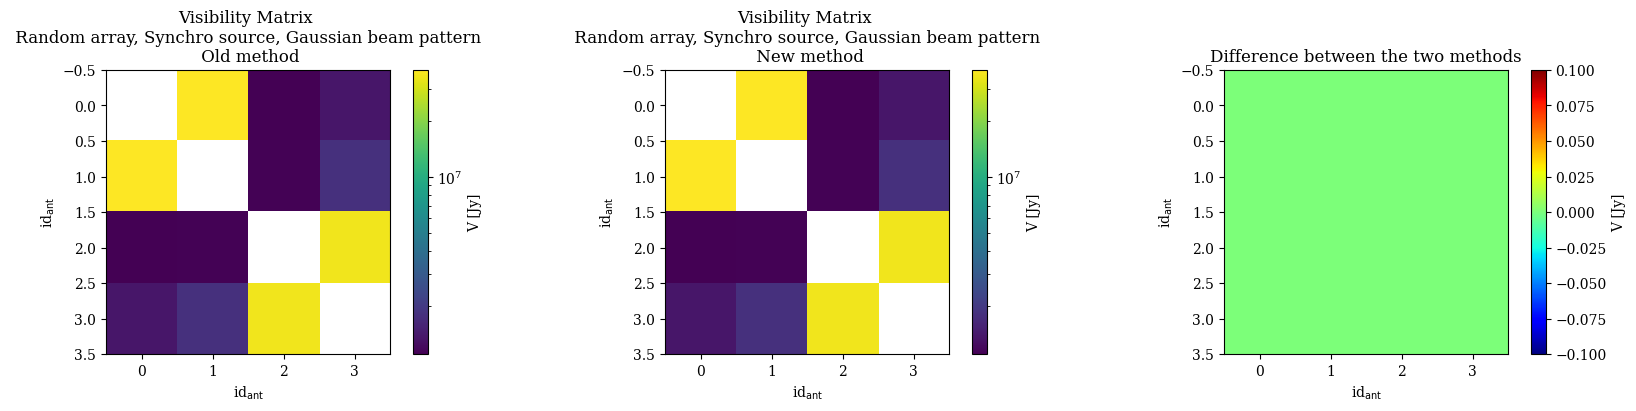

In [14]:
fig, axes= plt.subplots(1, 3, figsize=(17, 4), constrained_layout= True)

visls_random1, vismx_random1, bl_random1= visibility_matrix_func(xyz_random, lmn_coord, rshift, synchro_source, beam_pattern)
visls_random2, vismx_random2, bl_random2= visibility_matrix_func_new_method(xyz_random, thet, rshift, synchro_source, beam_pattern)

im0= axes[0].imshow(np.abs(vismx_random1), cmap='viridis', norm=LogNorm())
axes[0].set_xlabel(r'id$_\mathrm{ant}$')
axes[0].set_ylabel(r'id$_\mathrm{ant}$')
axes[0].set_title('Visibility Matrix \n Random array, Synchro source, Gaussian beam pattern \n Old method')
axes[0].set_box_aspect(1)
plt.colorbar(im0, ax=axes[0], label='V [Jy]')

im1= axes[1].imshow(np.abs(vismx_random2), cmap='viridis', norm=LogNorm())
axes[1].set_xlabel(r'id$_\mathrm{ant}$')
axes[1].set_ylabel(r'id$_\mathrm{ant}$')
axes[1].set_title('Visibility Matrix \n Random array, Synchro source, Gaussian beam pattern \n New method')
axes[1].set_box_aspect(1)
plt.colorbar(im1, ax=axes[1], label='V [Jy]')

im2= axes[2].imshow(np.abs(vismx_random1 - vismx_random2), cmap='jet')
axes[2].set_xlabel(r'id$_\mathrm{ant}$')
axes[2].set_ylabel(r'id$_\mathrm{ant}$')
axes[2].set_title('Difference between the two methods')
#axes[2].grid()
axes[2].set_box_aspect(1)
plt.colorbar(im2, ax=axes[2], label='V [Jy]')
plt.show()

In [15]:
#Confirm once more that the two methods are equivalent
visls_grid1, vismx_grid1, bl_grid1= visibility_matrix_func(xyz_grid, lmn_coord, rshift, synchro_source, beam_pattern)
visls_grid2, vismx_grid2, bl_grid2= visibility_matrix_func_new_method(xyz_grid, thet, rshift, synchro_source, beam_pattern)

print(vismx_grid1 - vismx_grid2)
print(visls_grid1 - visls_grid2)

100%|██████████| 6/6 [00:00<00:00, 585.71it/s]

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


## __Plotting the visibility w.r.t. the norm of the baseline vector.__

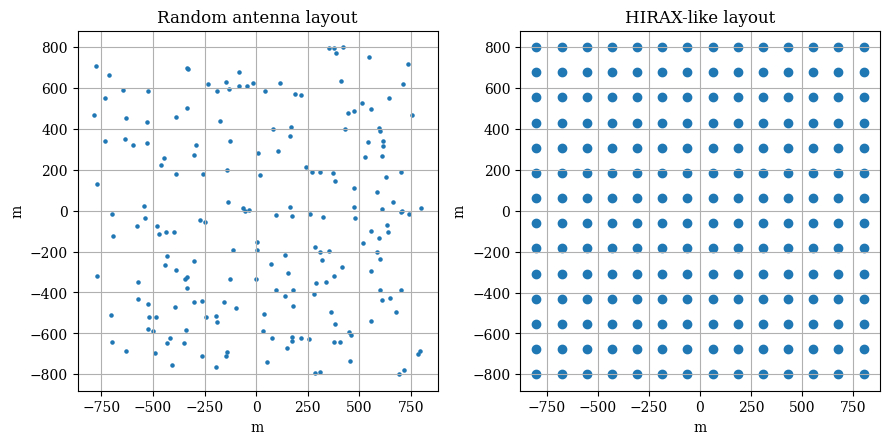

In [16]:
FoV= 4.*u.deg

# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, 128).to('rad').value

# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

#***********************************************
#Generate the coordinates of the telescope layout
xyz_grid= hirax_layout(14**2, [-800., 800.])
xyz_random= random_layout(14**2, [-800., 800.], 2024)
#***********************************************

#Angular diameter distance (in Mpc) for a specified redshift and FoV in deg
rshift=8.52
ang_dim_dist= FoV.to('rad').value * cosmo.angular_diameter_distance(rshift).value

#Gaussian and synchrotron sources, beam pattern
gaussian_source= gaussian_source_2d(l_coord, m_coord, [0.1, 0.1])
synchro_source, l= galactic_synch_fg_custom(z=[rshift], ncells=len(thet), boxsize=ang_dim_dist, rseed=2024)
beam_pattern= telescope_beam_pattern(l_coord, m_coord)

#***********************************************
fig, axes= plt.subplots(1, 2, figsize=(9, 7))

axes[0].scatter(xyz_random[:, 0], xyz_random[:, 1], s=5)
axes[0].set_xlabel("m")
axes[0].set_ylabel("m")
axes[0].set_title("Random antenna layout")
axes[0].grid()
axes[0].set_box_aspect(1)

axes[1].scatter(xyz_grid[:,0], xyz_grid[:, 1])
axes[1].set_xlabel("m")
axes[1].set_ylabel("m")
axes[1].set_title("HIRAX-like layout")
axes[1].grid()
axes[1].set_box_aspect(1)

plt.tight_layout()
plt.show()

In [17]:
visls_grid_synchro, vismx_grid_synchro, bl_grid_synchro= visibility_matrix_func_new_method(xyz_grid, thet, rshift, synchro_source, np.ones(l_coord.shape))
visls_grid_gaussian, vismx_grid_gaussian, bl_grid_gaussian= visibility_matrix_func_new_method(xyz_grid, thet, rshift, gaussian_source, np.ones(l_coord.shape))

visls_random_synhro, vismx_random_synchro, bl_random_synchro= visibility_matrix_func_new_method(xyz_random, thet, rshift, synchro_source, np.ones(l_coord.shape))
visls_random_gaussian, vismx_random_gaussian, bl_random_gaussian= visibility_matrix_func_new_method(xyz_random, thet, rshift, gaussian_source, np.ones(l_coord.shape))

visls_grid_uniform, vismx_grid_uniform, bl_grid_uniform= visibility_matrix_func_new_method(xyz_grid, thet, rshift, np.ones(l_coord.shape), np.ones(l_coord.shape))
visls_random_uniform, vismx_random_uniform, bl_random_uniform= visibility_matrix_func_new_method(xyz_random, thet, rshift, np.ones(l_coord.shape), np.ones(l_coord.shape))

#Defning a delta source at the center of the grid
delta_source= np.zeros((len(thet), len(thet)))
delta_source[63,63]= 30000
visls_grid_delta, vismx_grid_delta, bl_grid_delta= visibility_matrix_func_new_method(xyz_grid, thet, rshift, delta_source, np.ones(l_coord.shape))
visls_random_delta, vismx_random_delta, bl_random_delta= visibility_matrix_func_new_method(xyz_random, thet, rshift, delta_source, np.ones(l_coord.shape))

100%|██████████| 19110/19110 [00:28<00:00, 663.14it/s]


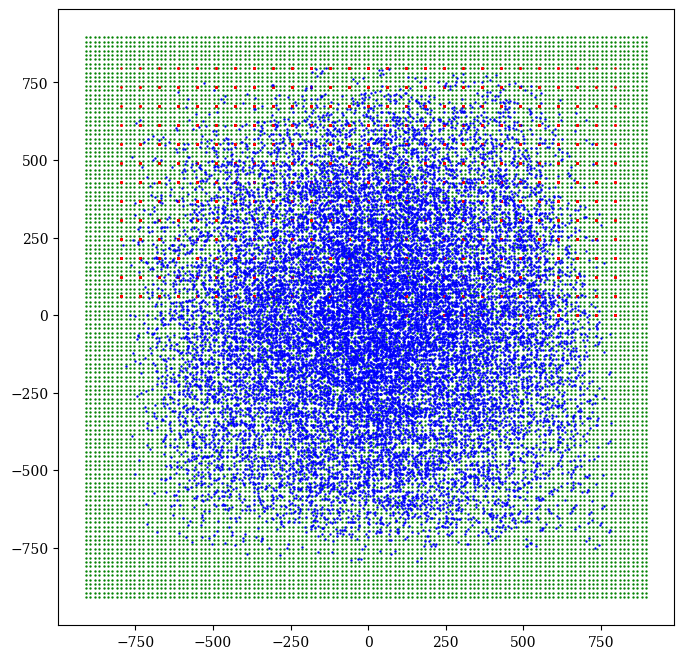

In [18]:
# Computing the frequency range of the FFT image
uu= np.fft.fftfreq(synchro_source.shape[0], np.diff(thet)[0])
vv= np.fft.fftfreq(synchro_source.shape[1], np.diff(thet)[0])
uu= np.fft.fftshift(uu)
vv= np.fft.fftshift(vv)
u_freq, v_freq= np.meshgrid(uu, vv)

fig, axes= plt.subplots(1, 1, figsize=(8, 8))
axes.scatter(u_freq, v_freq, color='green', s=0.5)
axes.scatter(bl_grid_synchro[:, 0], bl_grid_synchro[:, 1], color='red', s=0.5, label="Grid layout")
axes.scatter(bl_random_synchro[:, 0], bl_random_synchro[:, 1], color='blue', s=0.5, label="Random layout")
axes.set_box_aspect(1)

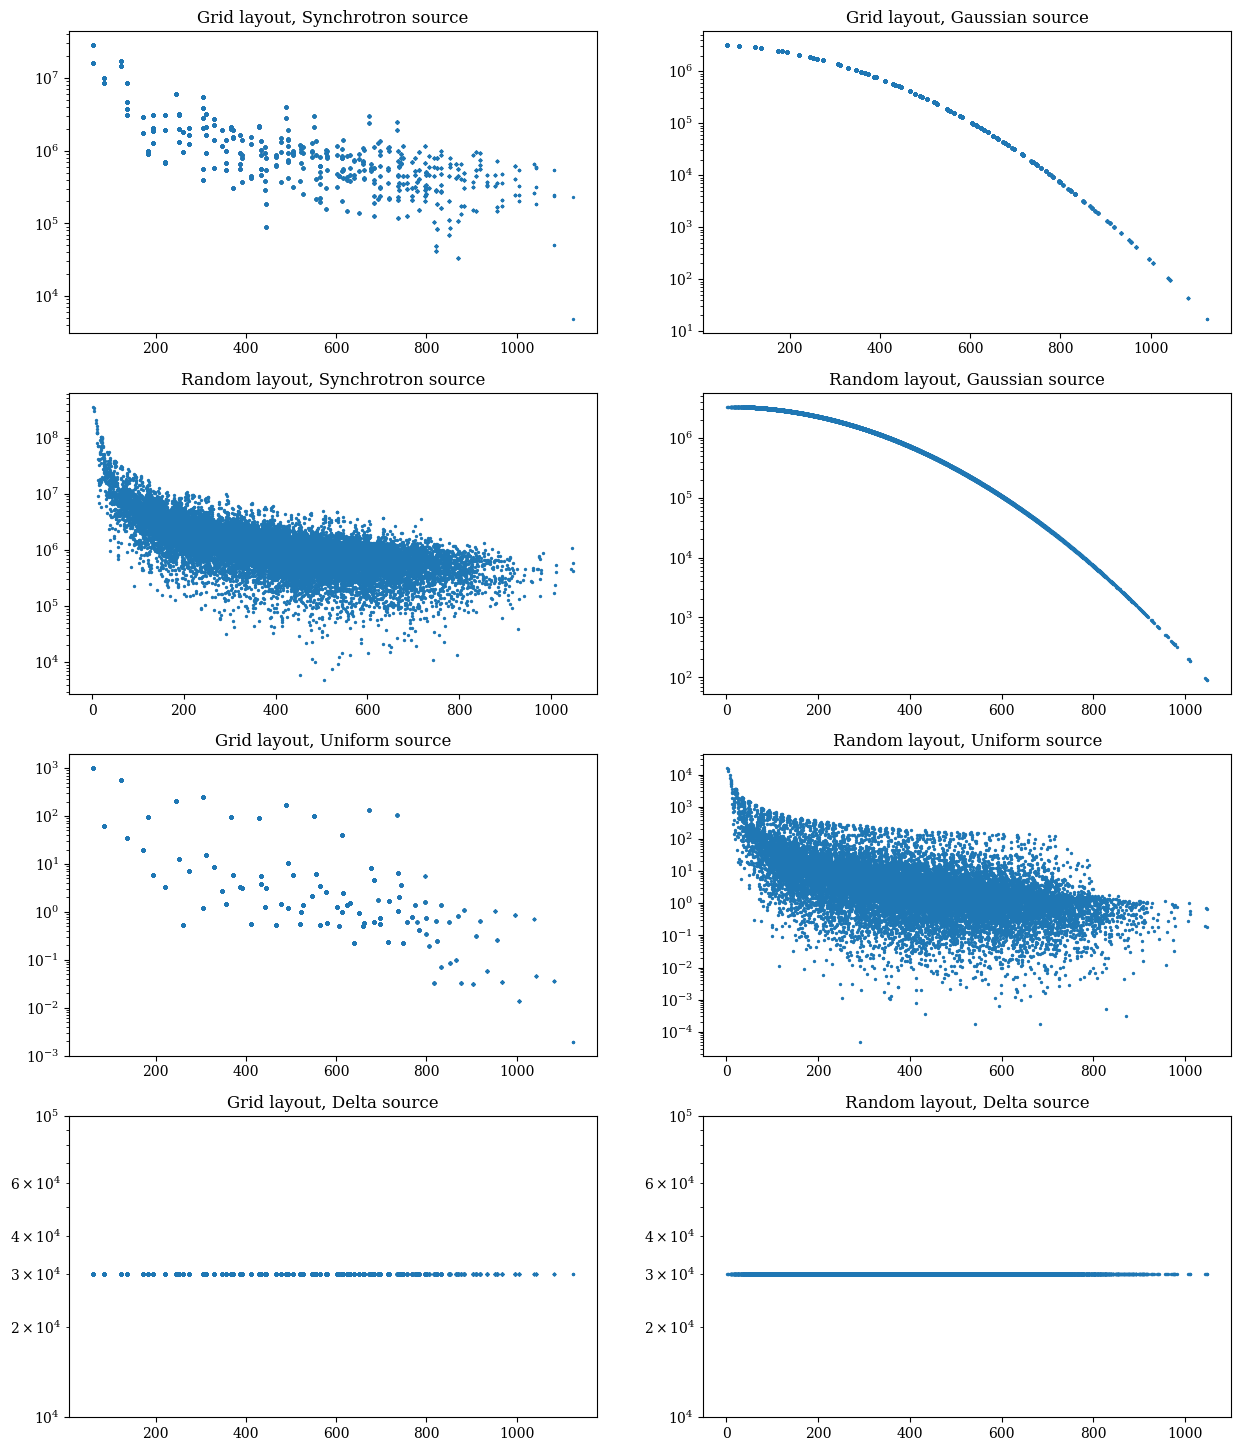

In [19]:
fig, axes= plt.subplots(4, 2, figsize=(15, 18))

axes[0,0].scatter(np.linalg.norm(bl_grid_synchro, axis=1), np.abs(visls_grid_synchro), s=2)
axes[0,0].set_title("Grid layout, Synchrotron source")
axes[0,0].set_yscale('log')

axes[0,1].scatter(np.linalg.norm(bl_grid_gaussian, axis=1), np.abs(visls_grid_gaussian), s=2)
axes[0,1].set_title("Grid layout, Gaussian source")
axes[0,1].set_yscale('log')

axes[1,0].scatter(np.linalg.norm(bl_random_synchro, axis=1), np.abs(visls_random_synhro), s=2)
axes[1,0].set_title("Random layout, Synchrotron source")
axes[1,0].set_yscale('log')

axes[1,1].scatter(np.linalg.norm(bl_random_gaussian, axis=1), np.abs(visls_random_gaussian), s=2)
axes[1,1].set_title("Random layout, Gaussian source")
axes[1,1].set_yscale('log')

axes[2,0].scatter(np.linalg.norm(bl_grid_uniform, axis=1), np.abs(visls_grid_uniform), s=2)
axes[2,0].set_title("Grid layout, Uniform source")
axes[2,0].set_yscale('log')

axes[2,1].scatter(np.linalg.norm(bl_random_uniform, axis=1), np.abs(visls_random_uniform), s=2)
axes[2,1].set_title("Random layout, Uniform source")
axes[2,1].set_yscale('log')

axes[3,0].scatter(np.linalg.norm(bl_grid_delta, axis=1), np.abs(visls_grid_delta), s=2)
axes[3,0].set_title("Grid layout, Delta source")
axes[3,0].set_yscale('log')

axes[3,1].scatter(np.linalg.norm(bl_random_delta, axis=1), np.abs(visls_random_delta), s=2)
axes[3,1].set_title("Random layout, Delta source")
axes[3,1].set_yscale('log')

## __Plotting the images recostructed from visibilities.__

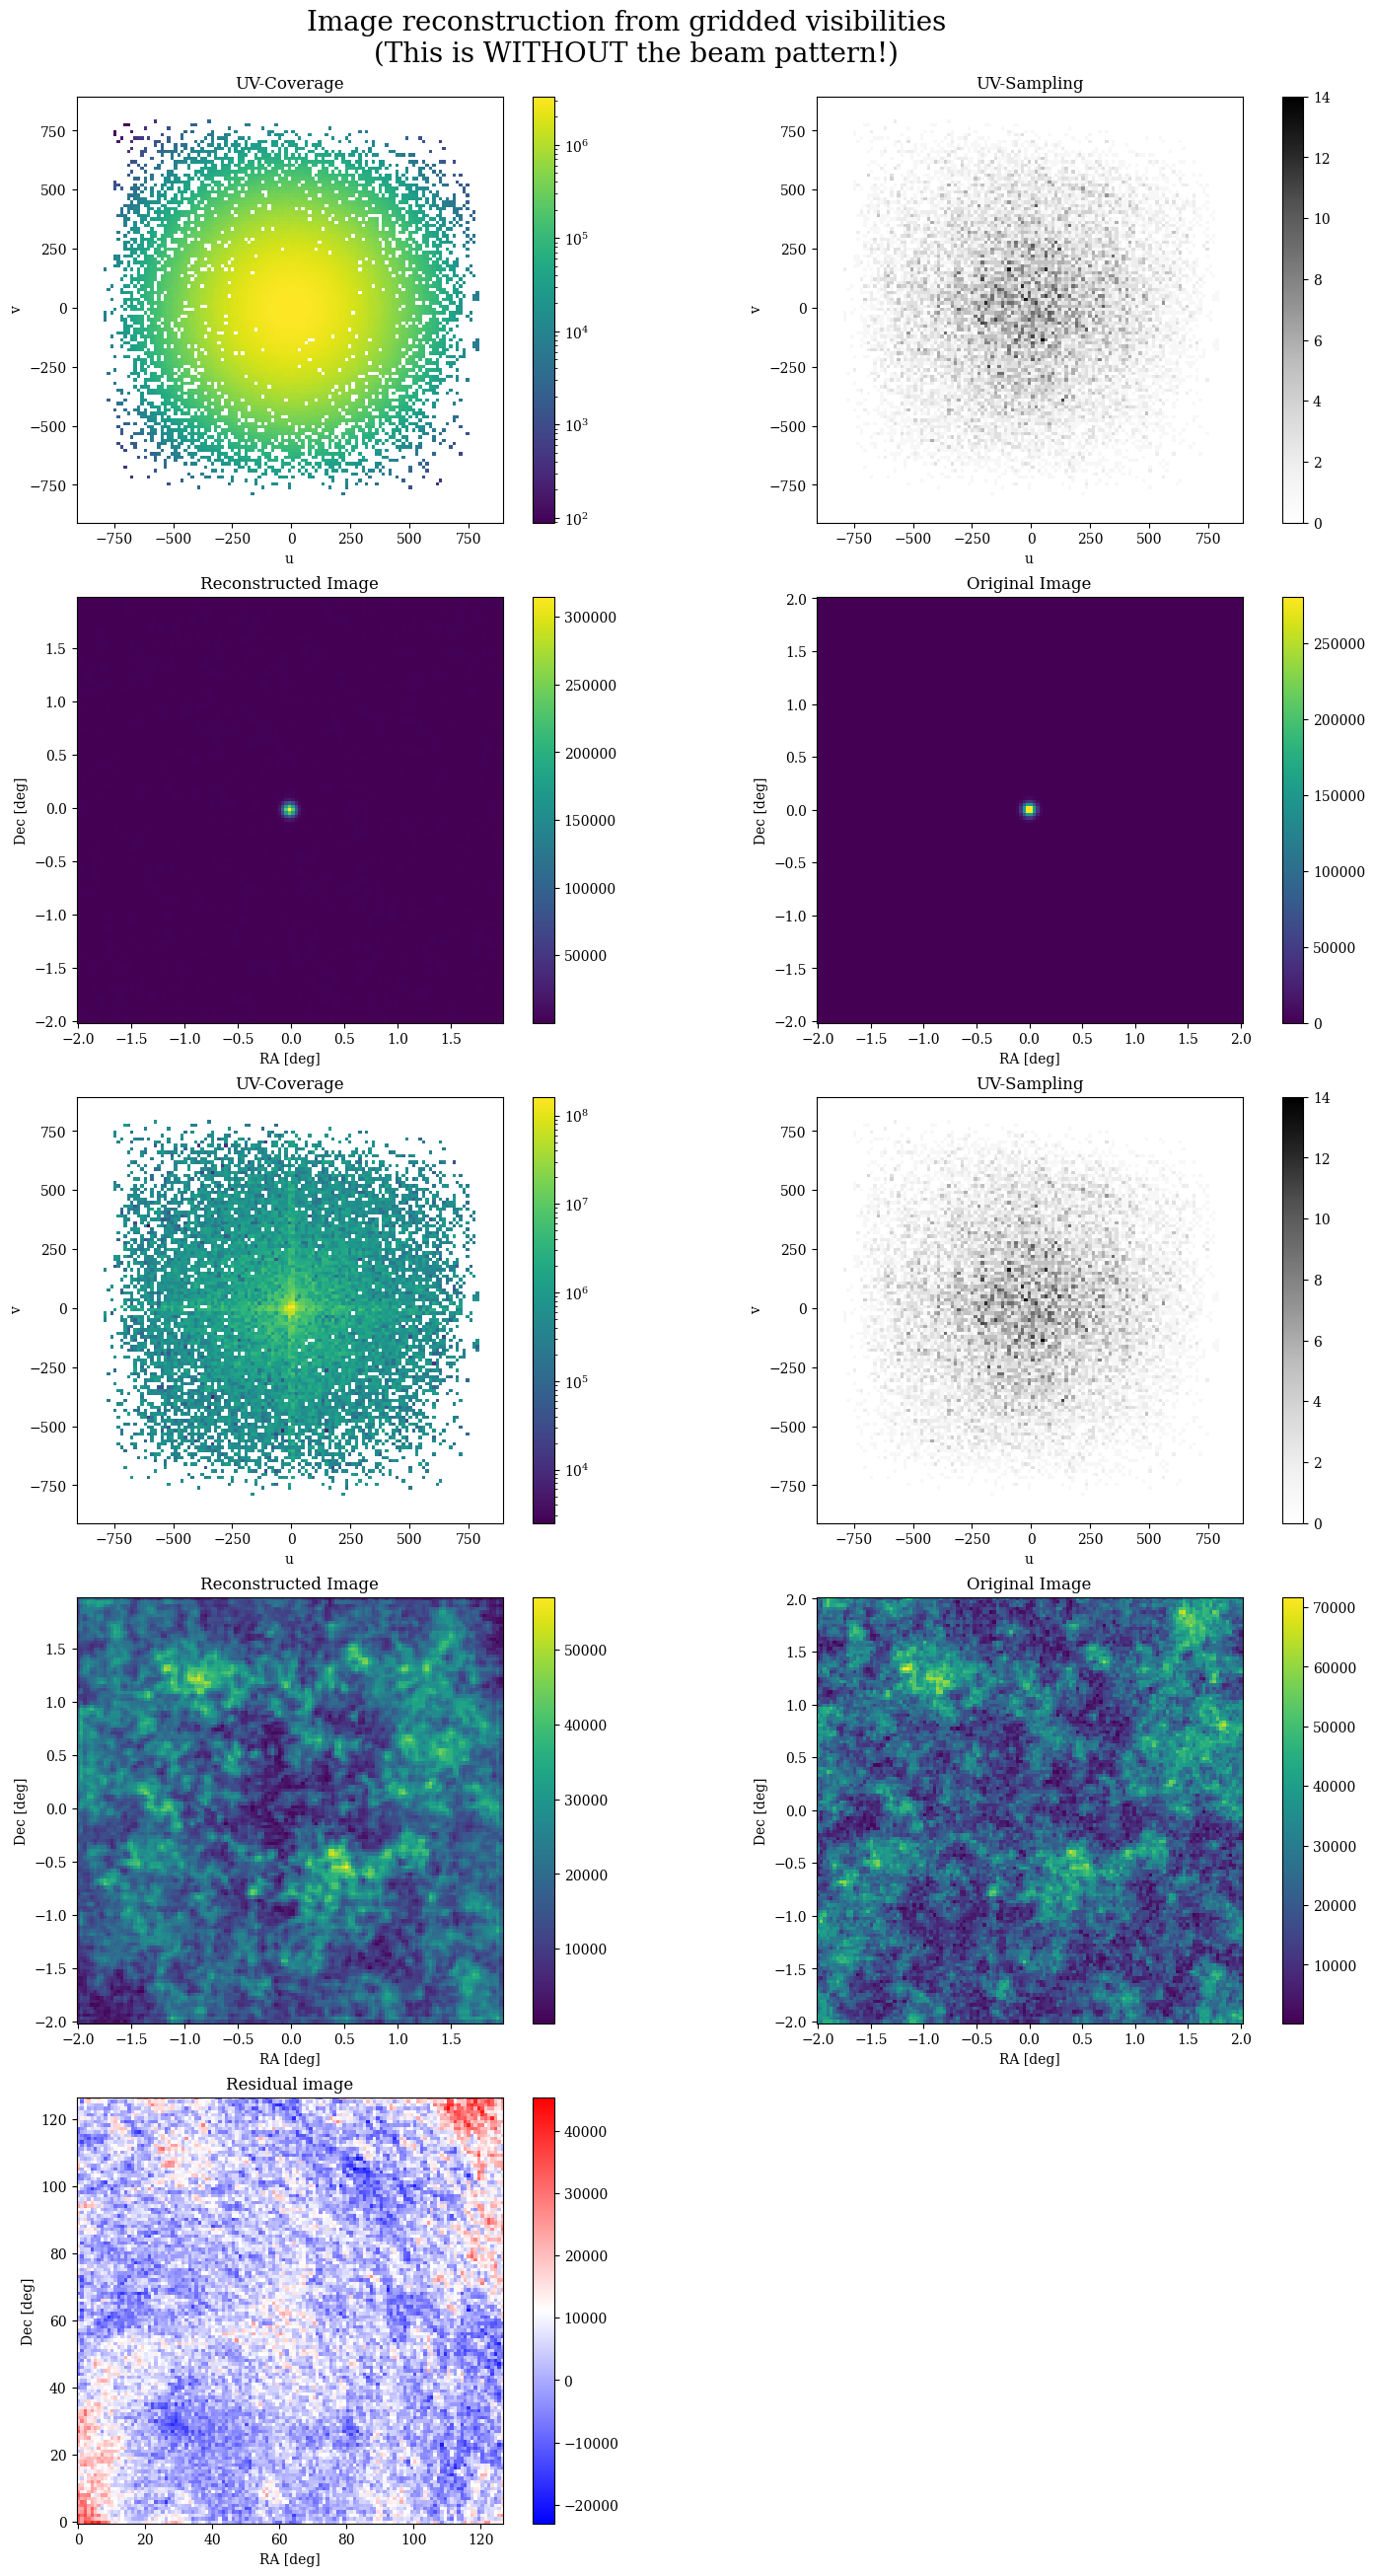

In [20]:
fig, axs= plt.subplots(figsize=(15, 26), ncols=2, nrows=5, constrained_layout=True)

fig.suptitle("Image reconstruction from gridded visibilities \n (This is WITHOUT the beam pattern!)", fontsize=20)

# Plot the reconstructed image
binned_random_gaussian, uv_bin_random_gaussian, uv_sampl_random_gaussian, x_random_gaussian= image_reconstructing_func(visls_random_gaussian, 
                                                                                                bl_random_gaussian, uu[0], uu[-1], len(uu), 1)

# Plot gridded visibilities
im0= axs[0,0].pcolormesh(uv_bin_random_gaussian, uv_bin_random_gaussian, np.abs(binned_random_gaussian), norm=LogNorm(), cmap='viridis')
axs[0,0].set_title('UV-Coverage')
axs[0,0].set_xlabel('u')
axs[0,0].set_ylabel('v')
axs[0,0].set_box_aspect(1)
plt.colorbar(im0, ax=axs[0,0])

im1= axs[0,1].pcolormesh(uv_bin_random_gaussian, uv_bin_random_gaussian, uv_sampl_random_gaussian, cmap='Greys')
axs[0,1].set_title('UV-Sampling')
axs[0,1].set_xlabel('u')
axs[0,1].set_ylabel('v')
axs[0,1].set_box_aspect(1)
plt.colorbar(im1, ax=axs[0,1])

im2= axs[1,0].pcolormesh(np.rad2deg(x_random_gaussian*u.rad).value, np.rad2deg(x_random_gaussian*u.rad).value, 
                         np.fft.fftshift(np.abs(np.fft.ifft2(binned_random_gaussian))), cmap='viridis')
axs[1,0].set_title('Reconstructed Image')
axs[1,0].set_xlabel('RA [deg]')
axs[1,0].set_ylabel('Dec [deg]')
axs[1,0].set_box_aspect(1)
plt.colorbar(im2, ax=axs[1,0])

im3= axs[1,1].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, gaussian_source, cmap='viridis')
axs[1,1].set_title('Original Image')
axs[1,1].set_xlabel('RA [deg]')
axs[1,1].set_ylabel('Dec [deg]')
axs[1,1].set_box_aspect(1)
plt.colorbar(im3, ax=axs[1,1])

#Plot another reconstructed image
binned_random_synchro, uv_bin_random_synchro, us_sampl_random_synchro, x_random_synchro= image_reconstructing_func(visls_random_synhro, 
                                                                                            bl_random_synchro, uu[0], uu[-1], len(uu), 1)

# Plot gridded visibilities
im4= axs[2,0].pcolormesh(uv_bin_random_synchro, uv_bin_random_synchro, np.abs(binned_random_synchro), norm=LogNorm(), cmap='viridis')
axs[2,0].set_title('UV-Coverage')
axs[2,0].set_xlabel('u')
axs[2,0].set_ylabel('v')
axs[2,0].set_box_aspect(1)
plt.colorbar(im4, ax=axs[2,0])

im5= axs[2,1].pcolormesh(uv_bin_random_synchro, uv_bin_random_synchro, us_sampl_random_synchro, cmap='Greys')
axs[2,1].set_title('UV-Sampling')
axs[2,1].set_xlabel('u')
axs[2,1].set_ylabel('v')
axs[2,1].set_box_aspect(1)
plt.colorbar(im5, ax=axs[2,1])

synchro_reconstructed_rotflip= np.flip(np.rot90(np.fft.fftshift(np.abs(np.fft.ifft2(binned_random_synchro))), k=-1), axis=1)
im6= axs[3,0].pcolormesh(np.rad2deg(x_random_synchro*u.rad).value, np.rad2deg(x_random_synchro*u.rad).value,
                        synchro_reconstructed_rotflip, cmap='viridis')
axs[3,0].set_title('Reconstructed Image')
axs[3,0].set_xlabel('RA [deg]')
axs[3,0].set_ylabel('Dec [deg]')
axs[3,0].set_box_aspect(1)
plt.colorbar(im6, ax=axs[3,0])

im7= axs[3,1].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, synchro_source, cmap='viridis')
axs[3,1].set_title('Original Image')
axs[3,1].set_xlabel('RA [deg]')
axs[3,1].set_ylabel('Dec [deg]')
axs[3,1].set_box_aspect(1)
plt.colorbar(im7, ax=axs[3,1])

im8= axs[4,0].imshow(synchro_source[:-1, :-1] - synchro_reconstructed_rotflip, cmap='bwr', origin='lower')
axs[4,0].set_title('Residual image')
axs[4,0].set_xlabel('RA [deg]')
axs[4,0].set_ylabel('Dec [deg]')
axs[4,0].set_box_aspect(1)
plt.colorbar(im8, ax=axs[4,0])

fig.delaxes(axs[4, 1])

100%|██████████| 19110/19110 [00:52<00:00, 364.54it/s]


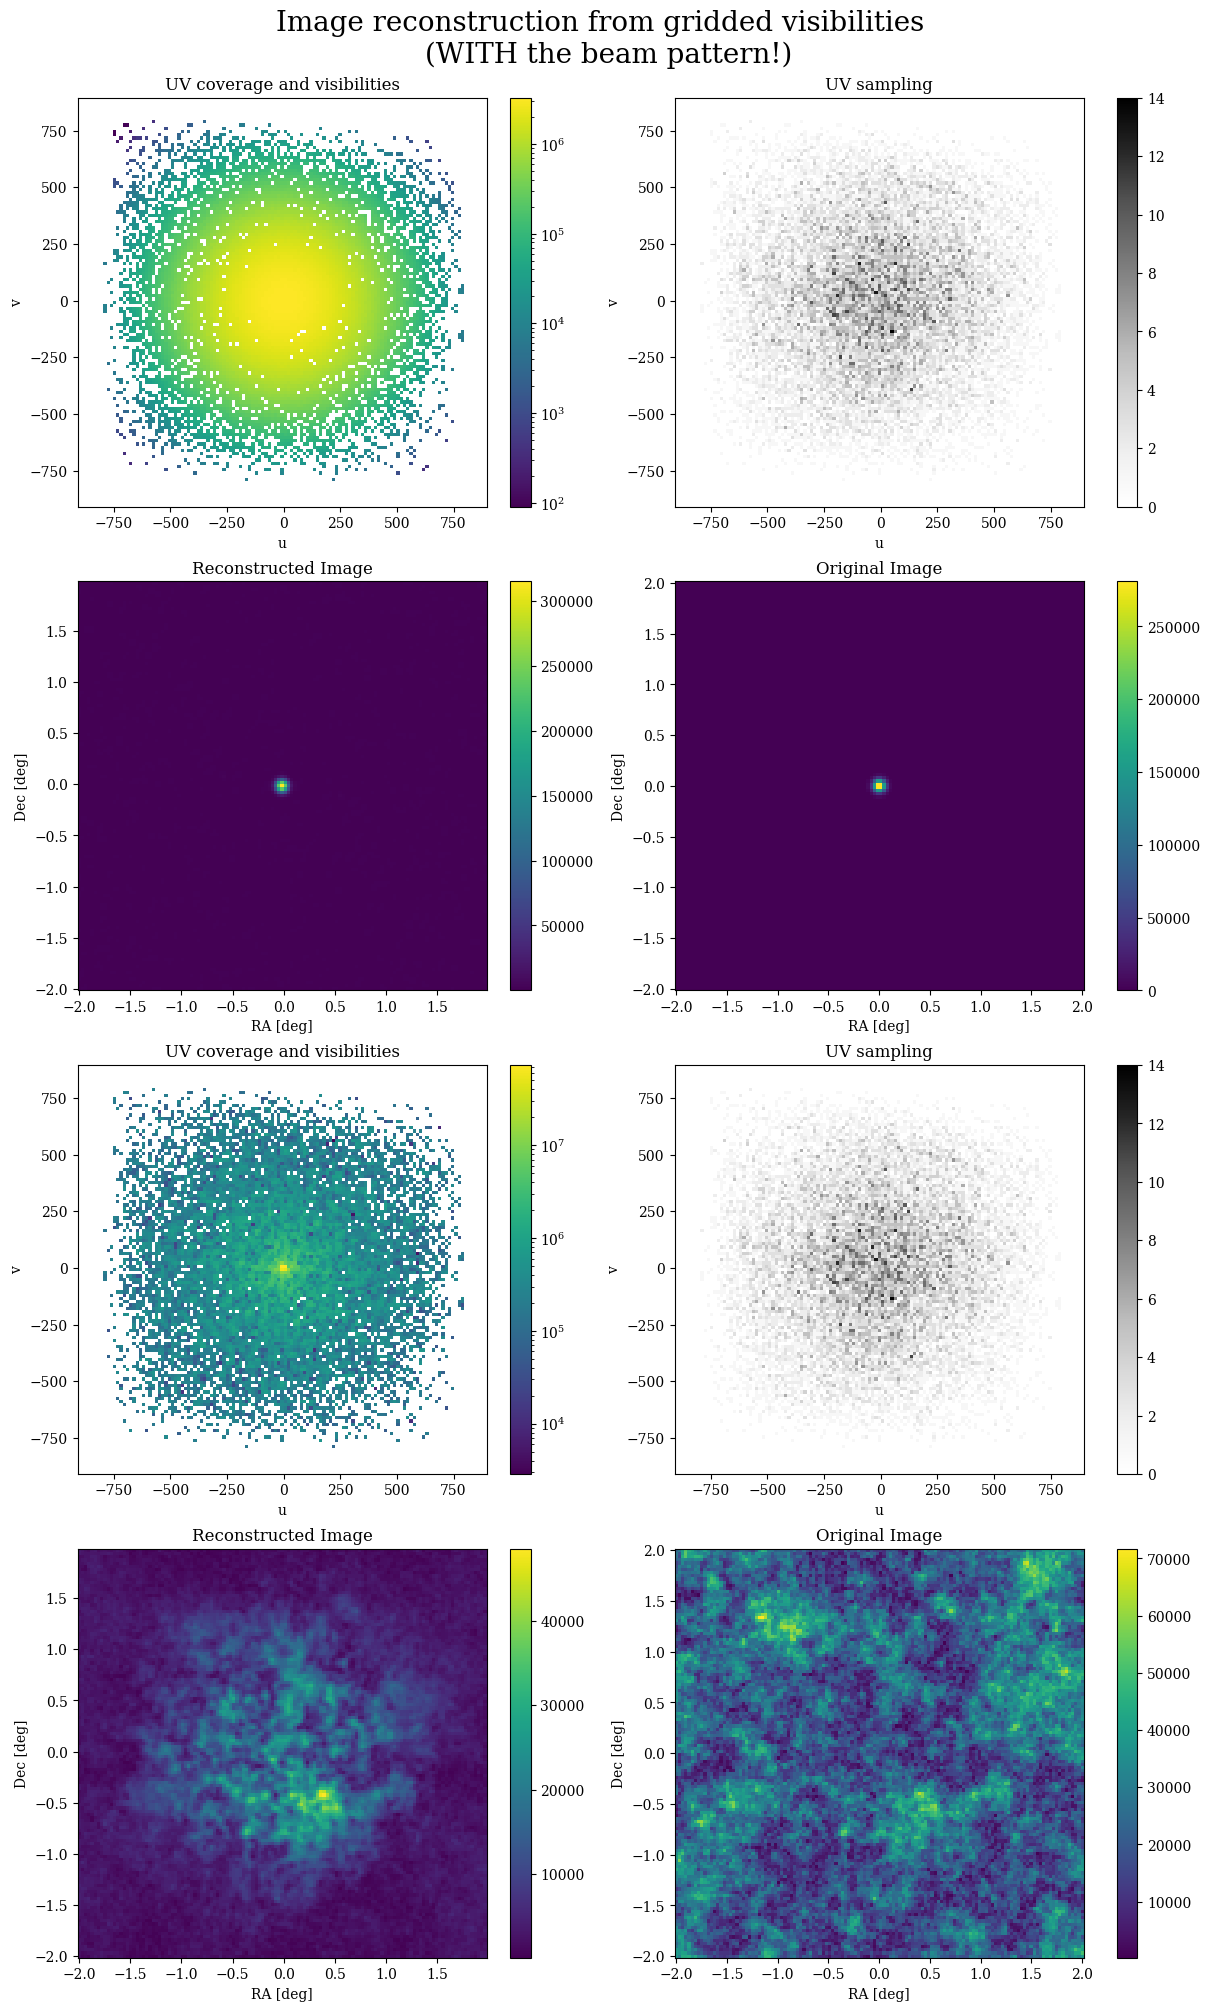

In [21]:
fig, axs= plt.subplots(figsize=(12, 20), ncols=2, nrows=4, constrained_layout=True)

fig.suptitle("Image reconstruction from gridded visibilities \n (WITH the beam pattern!)", fontsize=20)

visls_random_gaussian, vismx_random_gaussian, bl_random_gaussian= visibility_matrix_func_new_method(xyz_random, thet, rshift, gaussian_source, beam_pattern)
bin_random_gaussian, uvbin_random_gaussian, uvsampl_random_gaussian, x_random_gaussian= image_reconstructing_func(visls_random_gaussian, bl_random_gaussian, uu[0], uu[-1], len(uu), 1)

im00= axs[0,0].pcolormesh(uvbin_random_gaussian, uvbin_random_gaussian, np.abs(bin_random_gaussian), norm=LogNorm(), cmap='viridis')
axs[0,0].set_title('UV coverage and visibilities')
axs[0,0].set_xlabel('u')
axs[0,0].set_ylabel('v')
axs[0,0].set_box_aspect(1)
plt.colorbar(im00, ax=axs[0,0])

im01= axs[0,1].pcolormesh(uvbin_random_gaussian, uvbin_random_gaussian, uvsampl_random_gaussian, cmap='Greys')
axs[0,1].set_title('UV sampling')
axs[0,1].set_xlabel('u')
axs[0,1].set_ylabel('v')
axs[0,1].set_box_aspect(1)
plt.colorbar(im01, ax=axs[0,1])

img_random_gaussian_rotflip= np.flip(np.rot90(np.fft.fftshift(np.abs(np.fft.ifft2(bin_random_gaussian))), k=-1), axis=1)
im10= axs[1,0].pcolormesh(np.rad2deg(x_random_gaussian*u.rad).value, np.rad2deg(x_random_gaussian*u.rad).value, img_random_gaussian_rotflip, cmap='viridis')
axs[1,0].set_title('Reconstructed Image')
axs[1,0].set_xlabel('RA [deg]')
axs[1,0].set_ylabel('Dec [deg]')
axs[1,0].set_box_aspect(1)
plt.colorbar(im10, ax=axs[1,0])

im11= axs[1,1].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, gaussian_source, cmap='viridis')
axs[1,1].set_title('Original Image')
axs[1,1].set_xlabel('RA [deg]')
axs[1,1].set_ylabel('Dec [deg]')
axs[1,1].set_box_aspect(1)
plt.colorbar(im11, ax=axs[1,1])


visls_random_synchro, vismx_random_synchro, bl_random_synchro= visibility_matrix_func_new_method(xyz_random, thet, rshift, synchro_source, beam_pattern)
bin_random_synchro, uvbin_random_synchro, uvsampl_random_synchro, x_random_synchro= image_reconstructing_func(visls_random_synchro, bl_random_synchro, uu[0], uu[-1], len(uu), 1)

im20= axs[2,0].pcolormesh(uvbin_random_synchro, uvbin_random_synchro, np.abs(bin_random_synchro), norm=LogNorm(), cmap='viridis')
axs[2,0].set_title('UV coverage and visibilities')
axs[2,0].set_xlabel('u')
axs[2,0].set_ylabel('v')
axs[2,0].set_box_aspect(1)
plt.colorbar(im20, ax=axs[2,0])

im21= axs[2,1].pcolormesh(uvbin_random_synchro, uvbin_random_synchro, uvsampl_random_synchro, cmap='Greys')
axs[2,1].set_title('UV sampling')
axs[2,1].set_xlabel('u')
axs[2,1].set_ylabel('v')
axs[2,1].set_box_aspect(1)
plt.colorbar(im21, ax=axs[2,1])

img_synchro_rotflip= np.flip(np.rot90(np.fft.fftshift(np.abs(np.fft.ifft2(bin_random_synchro))), k=-1), axis=1)
im30= axs[3,0].pcolormesh(np.rad2deg(x_random_synchro*u.rad).value, np.rad2deg(x_random_synchro*u.rad).value, img_synchro_rotflip, cmap='viridis')
axs[3,0].set_title('Reconstructed Image')
axs[3,0].set_xlabel('RA [deg]')
axs[3,0].set_ylabel('Dec [deg]')
axs[3,0].set_box_aspect(1)
plt.colorbar(im30, ax=axs[3,0])

im31= axs[3,1].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, synchro_source, cmap='viridis')
axs[3,1].set_title('Original Image')
axs[3,1].set_xlabel('RA [deg]')
axs[3,1].set_ylabel('Dec [deg]')
axs[3,1].set_box_aspect(1)
plt.colorbar(im31, ax=axs[3,1])

## __Testing different cylindrical power spectrum functions.__

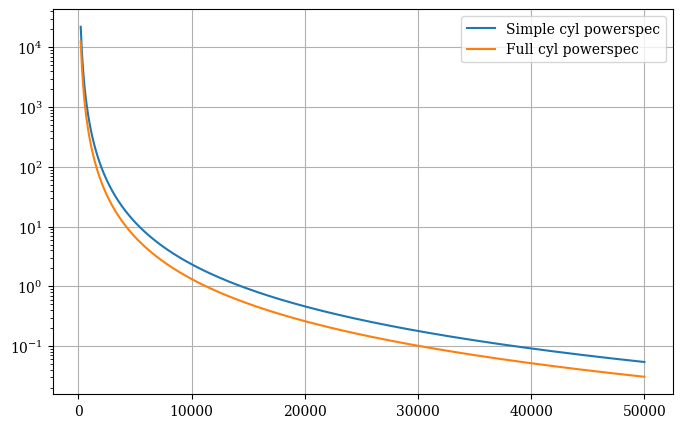

In [8]:
def simple_cyl_power_spec(ells, beta, A150):
    C_cyl = A150 * (1000 / ells) ** beta
    return C_cyl

def full_cyl_power_spec(ells, beta, A150, nu, nu_s, a_syn, Da_syn):
    C_syn = A150*(1000/ells)**beta_*(nu/nu_s)**(-2*a_syn-2*Da_syn*np.log(nu/nu_s))
    return C_syn

nu_s,A150,beta_,a_syn,Da_syn = 150,513,2.34,2.8,0.1
nu_s= 150
nu = 166
A150 = 513
beta = 2.34
a_syn = 2.8
Da_syn = 0.1

ells = np.linspace(200, 50 * 1e3, 1000)

fig, axs = plt.subplots(1, 1, figsize=(8, 5))

axs.plot(ells, simple_cyl_power_spec(ells, beta, A150), label='Simple cyl powerspec')
axs.plot(ells, full_cyl_power_spec(ells, beta, A150, nu, nu_s, a_syn, Da_syn), label='Full cyl powerspec')
axs.set_yscale('log')
axs.grid()
axs.legend()

## __Plotting the baseline distribution for a single timestep.__

In [68]:
all_bls = np.load('baselines_all_dTgf_32.npy', mmap_mode='r')
all_vis = np.load('visibilities_all_dTgf.npy', mmap_mode='r')
timestep = 0
num_times = 1440
timestep_len = len(all_bls) // num_times

bls = all_bls[timestep * timestep_len : (timestep + 1) * timestep_len]
vis= all_vis[timestep * timestep_len : (timestep + 1) * timestep_len]

In [69]:
# Compute the norm of each baseline vector
norms = np.linalg.norm(bls, axis=1)

# Filtering baselines with zero visibility
non_zero_indices = np.where(vis != 0)[0]
bls_nonzero = bls[non_zero_indices]
# Compute the norm of the non-zero baseline vectors
norms_nonzero = np.linalg.norm(bls_nonzero, axis=1)

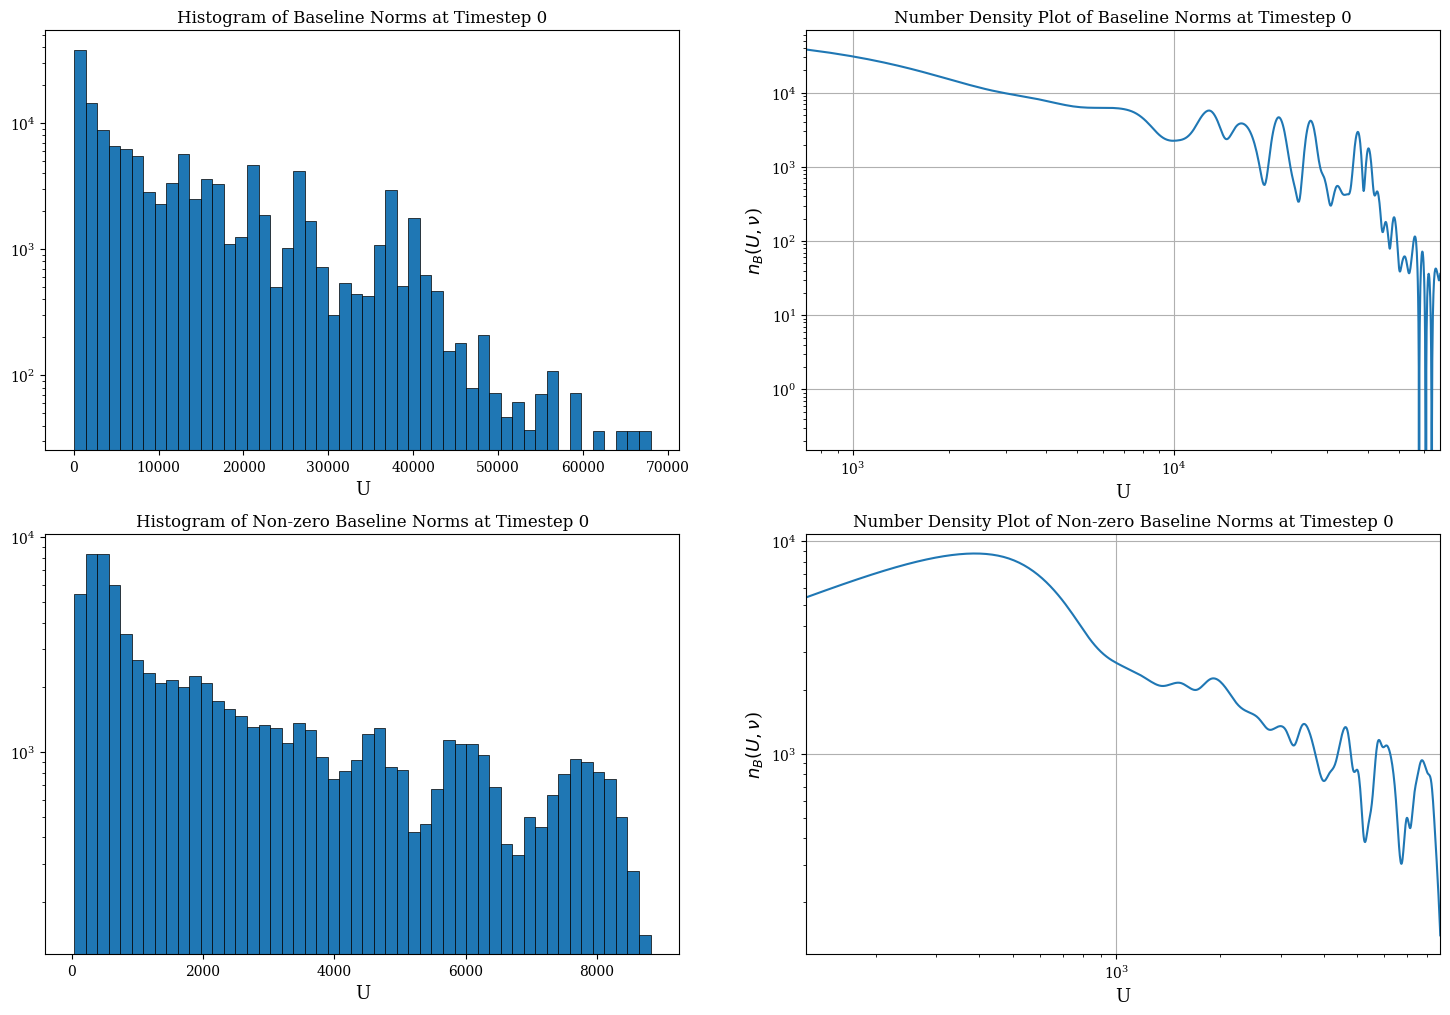

In [70]:
from scipy.interpolate import make_interp_spline

# Create the plot using subplots
fig, axs = plt.subplots(2, 2, figsize=(18, 12))

axs[0,0].hist(norms, bins=50, edgecolor='black', linewidth= 0.5)
axs[0,0].set_xlabel('U', fontsize= 13)
axs[0,0].set_yscale('log')
axs[0,0].set_title('Histogram of Baseline Norms at Timestep {}'.format(timestep))

# Compute the histogram for all baseline vectors
num_bins = 50
counts, bin_edges = np.histogram(norms, bins=num_bins)
# Calculate the bin midpoints and the interpolated curve
bin_midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2
spline = make_interp_spline(bin_midpoints, counts, k=3)
x_smooth = np.linspace(bin_midpoints.min(), bin_midpoints.max(), 500)
y_smooth = spline(x_smooth)

axs[0,1].plot(x_smooth, y_smooth)
axs[0,1].set_xlabel('U', fontsize= 13)
axs[0,1].set_ylabel(r'$n_B(U, \nu$)', fontsize= 13)
axs[0,1].set_xscale('log')
axs[0,1].set_yscale('log')
axs[0,1].grid()
axs[0,1].set_xlim([x_smooth.min(), x_smooth.max()])
axs[0,1].set_title('Number Density Plot of Baseline Norms at Timestep {}'.format(timestep))

axs[1,0].hist(norms_nonzero, bins=50, edgecolor='black', linewidth= 0.5)
axs[1,0].set_xlabel('U', fontsize= 13)
axs[1,0].set_yscale('log')
axs[1,0].set_title('Histogram of Non-zero Baseline Norms at Timestep {}'.format(timestep))

# Compute the histogram for all baseline vectors
counts_nonzero, bin_edges_nonzero = np.histogram(norms_nonzero, bins=num_bins)
# Calculate the bin midpoints and the interpolated curve
bin_midpoints_nonzero = (bin_edges_nonzero[:-1] + bin_edges_nonzero[1:]) / 2
spline = make_interp_spline(bin_midpoints_nonzero, counts_nonzero, k=3)
x_smooth_nonzero = np.linspace(bin_midpoints_nonzero.min(), bin_midpoints_nonzero.max(), 500)
y_smooth_nonzero = spline(x_smooth_nonzero)

axs[1,1].plot(x_smooth_nonzero, y_smooth_nonzero)
axs[1,1].set_xlabel('U', fontsize= 13)
axs[1,1].set_ylabel(r'$n_B(U, \nu$)', fontsize= 13)
axs[1,1].set_xscale('log')
axs[1,1].set_yscale('log')
axs[1,1].grid()
axs[1,1].set_xlim([x_smooth_nonzero.min(), x_smooth_nonzero.max()])
axs[1,1].set_title('Number Density Plot of Non-zero Baseline Norms at Timestep {}'.format(timestep))

# Show the plot
plt.show()

## __Bare estimator low baseline analysis; Rescaling the bare estimator.__

In [111]:
folder = 'output/'
#filename = 'NPARR_SKA_BE_0to19steps_nofilter_bins50_equal_length.npz'
#filename = 'NPARR_SKA_BE_0to1439steps_nofilter_bins20_equal_length.npz'
filename= 'NPARR_SKA_BE_0to1439steps_uvRngPm1000_bins30_equal_length.npz'
data = np.load(folder + filename)

# Access the arrays
bare_estimator_avg = data['bare_estimator_avg']
ell_mean_avg = data['ell_mean_avg']
var_squared_avg = data['var_squared_avg']

# Close the .npz file
data.close()

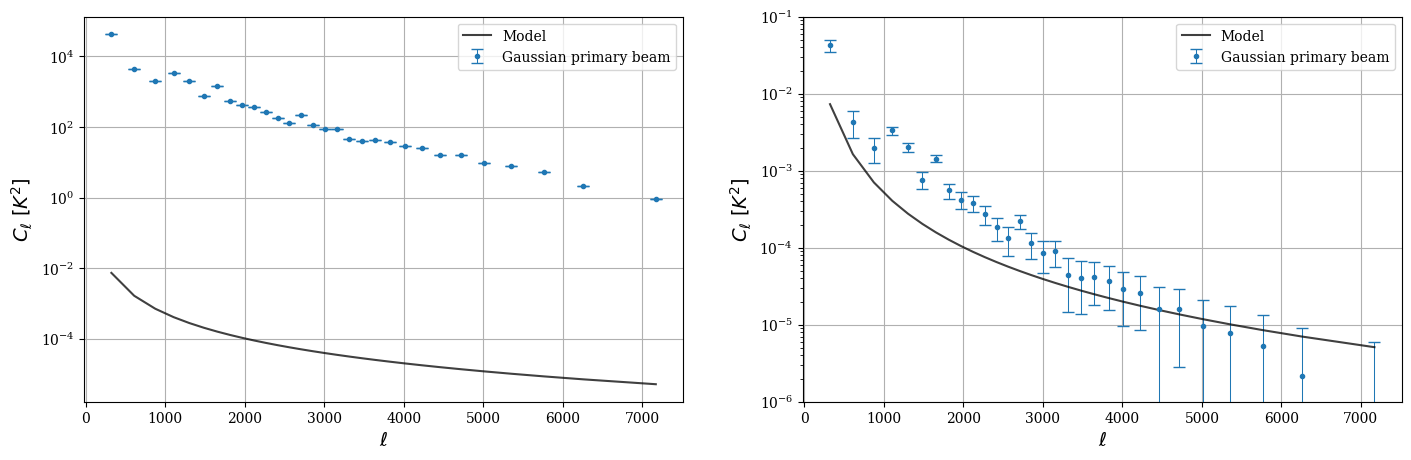

In [120]:
fig, axs = plt.subplots(1, 2, figsize=(17, 5))

axs[0].errorbar(ell_mean_avg, bare_estimator_avg, np.sqrt(var_squared_avg),
    color="#1f77b4", label="Gaussian primary beam", elinewidth=0.75, capsize=4, fmt="o", markersize=3)
axs[0].plot(ell_mean_avg, 5.13 * 1e-4 * (1000 / ell_mean_avg) ** 2.34,
    color="k", label="Model", alpha=0.75)
axs[0].set_yscale("log")
axs[0].grid()
axs[0].set_xlabel(r"$\ell$", fontsize=14)
axs[0].set_ylabel(r"$C_{\ell}$ $[K^2]$", fontsize=14)
#axs[0].set_xlim([ell_mean_avg.min(), ell_mean_avg[35]])
axs[0].legend()


axs[1].errorbar(ell_mean_avg, bare_estimator_avg / 1e6, np.sqrt(var_squared_avg),
    color="#1f77b4", label="Gaussian primary beam", elinewidth=0.75, capsize=4, fmt="o", markersize=3)

#axs[1].errorbar(ell_mean_avg, bare_estimator_avg / (1e6 * np.sqrt(2)), np.sqrt(var_squared_avg),
#    color="r", label="Gaussian primary beam", elinewidth=0.75, capsize=4, fmt="o", markersize=3)

axs[1].plot(ell_mean_avg, 5.13 * 1e-4 * (1000 / ell_mean_avg) ** 2.34,
    color="k", label="Model", alpha=0.75)
axs[1].set_yscale("log")
axs[1].grid()
axs[1].set_xlabel(r"$\ell$", fontsize=14)
axs[1].set_ylabel(r"$C_{\ell}$ $[K^2]$", fontsize=14)
#axs[1].set_xlim([ell_mean_avg.min(), ell_mean_avg[20]])
axs[1].set_ylim([1e-6, 1e-1])
axs[1].legend()

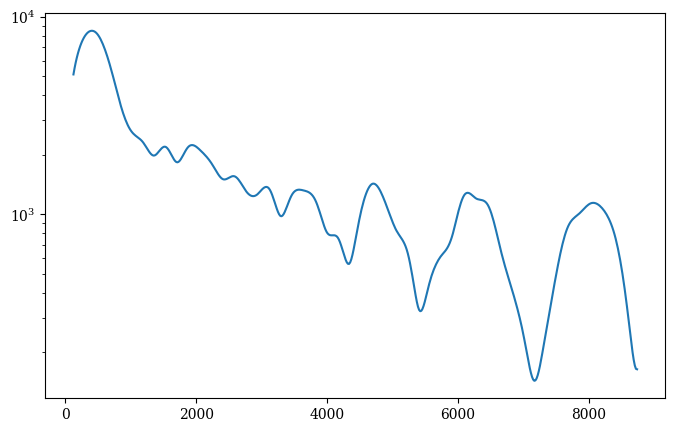

In [22]:
from scipy.interpolate import make_interp_spline

maxmin_norm = np.load('SKA_material/maxmin_norm.npy')
maxmin_norm_nonzero = np.load('SKA_material/maxmin_norm_nonzero.npy')
all_norms_nonzero_avg = np.load('SKA_material/all_norms_nonzero_avg.npy')

#Creating bins to bin all norms and non-zero norms.
num_bins = 50
bins = np.linspace(np.min(maxmin_norm[:,1]) - 1, np.max(maxmin_norm[:,0]) + 1, num_bins + 1)
bins_nonzero = np.linspace(np.min(maxmin_norm_nonzero[:,1]) - 1, np.max(maxmin_norm_nonzero[:,0]) + 1, num_bins + 1)

# Compute the bin midpoints for interpolation
bin_nonzero_midpoints = (bins_nonzero[:-1] + bins_nonzero[1:]) / 2

# Interpolate the average histograms for non-zero norms
spline_nonzero_norms = make_interp_spline(bin_nonzero_midpoints, all_norms_nonzero_avg, k=3)
x_smooth_nonzero_all_norms = np.linspace(bin_nonzero_midpoints.min(), bin_nonzero_midpoints.max(), 500)
y_smooth_nonzero_all_norms = spline_nonzero_norms(x_smooth_nonzero_all_norms)


fig, axs = plt.subplots(1, 1, figsize=(8, 5))
axs.plot(x_smooth_nonzero_all_norms, y_smooth_nonzero_all_norms)
axs.set_yscale('log')


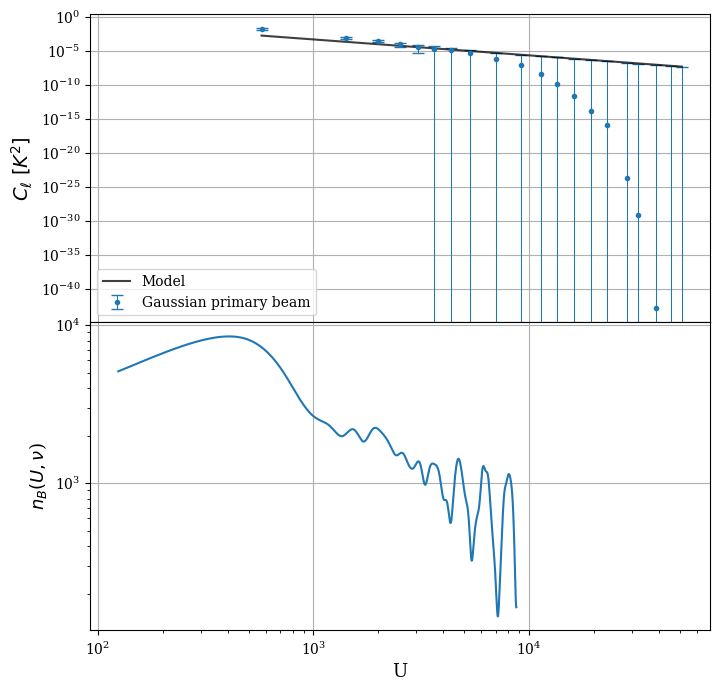

In [29]:
from scipy.interpolate import make_interp_spline

folder = 'output/'
filename= 'NPARR_SKA_BE_0to1439steps_nofilter_bins20_equal_length.npz'
data = np.load(folder + filename)

# Access the arrays
bare_estimator_avg = data['bare_estimator_avg']
ell_mean_avg = data['ell_mean_avg']
var_squared_avg = data['var_squared_avg']

# Close the .npz file
data.close()


maxmin_norm = np.load('SKA_material/maxmin_norm.npy')
maxmin_norm_nonzero = np.load('SKA_material/maxmin_norm_nonzero.npy')
all_norms_nonzero_avg = np.load('SKA_material/all_norms_nonzero_avg.npy')

#Creating bins to bin all norms and non-zero norms.
num_bins = 50
bins = np.linspace(np.min(maxmin_norm[:,1]) - 1, np.max(maxmin_norm[:,0]) + 1, num_bins + 1)
bins_nonzero = np.linspace(np.min(maxmin_norm_nonzero[:,1]) - 1, np.max(maxmin_norm_nonzero[:,0]) + 1, num_bins + 1)

# Compute the bin midpoints for interpolation
bin_nonzero_midpoints = (bins_nonzero[:-1] + bins_nonzero[1:]) / 2

# Interpolate the average histograms for non-zero norms
spline_nonzero_norms = make_interp_spline(bin_nonzero_midpoints, all_norms_nonzero_avg, k=3)
x_smooth_nonzero_all_norms = np.linspace(bin_nonzero_midpoints.min(), bin_nonzero_midpoints.max(), 500)
y_smooth_nonzero_all_norms = spline_nonzero_norms(x_smooth_nonzero_all_norms)



fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex= True)
# Remove vertical space between Axes
fig.subplots_adjust(hspace=0)

axs[0].errorbar(ell_mean_avg, bare_estimator_avg / 1e6, np.sqrt(var_squared_avg),
    color="#1f77b4", label="Gaussian primary beam", elinewidth=0.75, capsize=4, fmt="o", markersize=3)

axs[0].plot(ell_mean_avg, 5.13 * 1e-4 * (1000 / ell_mean_avg) ** 2.34,
    color="k", label="Model", alpha=0.75)
axs[0].set_yscale("log")
axs[0].set_xscale("log")
axs[0].grid()
axs[0].set_xlabel(r"$\ell$", fontsize=14)
axs[0].set_ylabel(r"$C_{\ell}$ $[K^2]$", fontsize=14)
#axs[0].set_ylim([1e-6, 1e-1])
axs[0].legend()


axs[1].plot(x_smooth_nonzero_all_norms, y_smooth_nonzero_all_norms)
axs[1].set_xlabel('U', fontsize= 13)
axs[1].set_ylabel(r'$n_B(U, \nu$)', fontsize= 13)
axs[1].set_yscale('log')
axs[0].set_xscale("log")
axs[1].grid()
#axs[1].set_xlim([x_smooth_nonzero_all_norms.min(), x_smooth_nonzero_all_norms.max()])

In [28]:
print(bins_nonzero[0])
print(bins_nonzero[-1])

36.486488342285156
8825.0732421875


## __Bare estimator for LOFAR data.__

### __1. Plotting baselines to see if they change for same timestep, but different frequencies.__

In [2]:
from matplotlib.animation import FuncAnimation

folder = 'LOFAR_material/'
all_baselines = np.load(folder + 'LOFAR_baselines.npy', mmap_mode='r')
all_visibilities = np.load(folder + 'LOFAR_visibilities.npy', mmap_mode='r')

print(all_baselines.shape)
print(all_visibilities.shape)
print(all_baselines[0, :, 0].shape)
print(all_baselines[0, :, 1])

(3595, 1891, 2)
(3595, 1891, 20)
(1891,)
[-5.43570873e+00  2.52905316e+02  2.58341025e+02 ...  1.48701066e+04
  3.89264281e+04  2.02860086e+04]


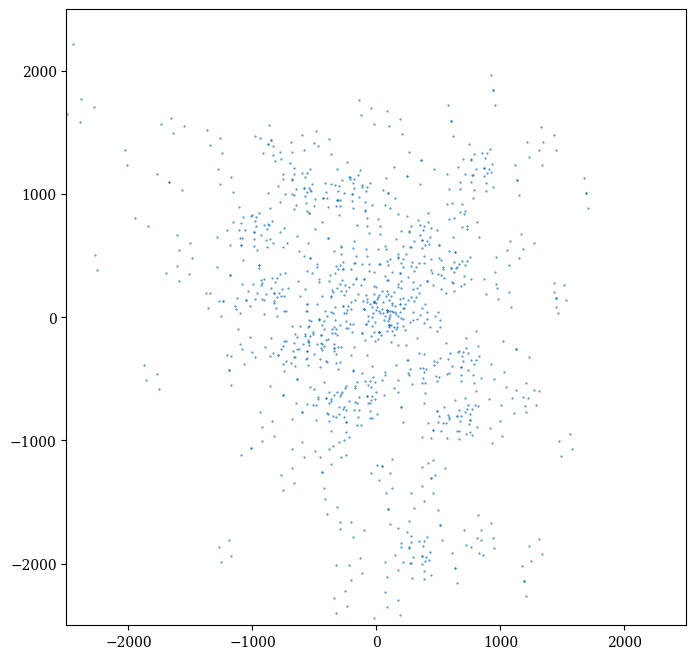

In [6]:
fig, axs = plt.subplots(1, 1, figsize=(8, 8))
scat = axs.scatter(all_baselines[0, :, 0], all_baselines[0, :, 1], s=0.2)
axs.set_xlim([-2.5 * 1e3, 2.5 * 1e3])
axs.set_ylim([-2.5 * 1e3, 2.5 * 1e3])

step_size = 3

# Function to update the scatter plot for each frame
def update(frame):
    scat.set_offsets(all_baselines[frame])
    return scat,

# Create the animation
ani = FuncAnimation(fig, update, frames=range(0, len(all_baselines), step_size), interval=50, blit=True)

# Save or show the animation
#ani.save('baselines_animation.gif', writer='pillow')
#plt.show()  # Uncomment this line if you want to display the animation instead of saving

In [25]:
folder = 'output/'
filename= 'NPARR_LOFAR_BE_0to3594timesteps_20freqsteps_nofilter_bins10_equal_length.npz'
data = np.load(folder + filename)

# Access the arrays
bare_estimator_avg = data['bare_estimator_avg']
ell_mean_avg = data['ell_mean_avg']
var_squared_avg = data['var_squared_avg']

# Close the .npz file
data.close()

In [33]:
bare_estimator_avg[:, 0]

array([           inf,            inf,            inf,            inf,
                  inf, 5.28930935e+16, 5.88213672e+13, 5.16239588e+13,
       1.27489684e+13, 1.10977910e+14, 6.33121179e+13, 6.04723132e+13,
                  inf, 3.59991106e+13, 1.90613760e+16,            inf,
       5.06723387e+15, 2.33987302e+15, 5.75427386e+15, 9.81993365e+14])

In [32]:
ell_mean_avg[:,0]

array([          nan,           nan,           nan,           nan,
                 nan, 1548.61465425, 1552.6205279 , 1550.10877227,
       1575.86831009, 1606.13298742, 1579.57116784, 1561.37977409,
                 nan, 1589.88686116, 1591.96033335,           nan,
       1620.45422767, 1631.46095529, 1639.68889101, 1796.9477016 ])

## __Some code to test for conversion from temperature to Jansky and vice versa.__

In [25]:
import os, numpy as np, os
import matplotlib.pyplot as plt
import tools21cm as t2c

import astropy.units as u
import astropy.constants as cst

from astropy.io import fits
from astropy.cosmology import Planck18 as cosmo
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time

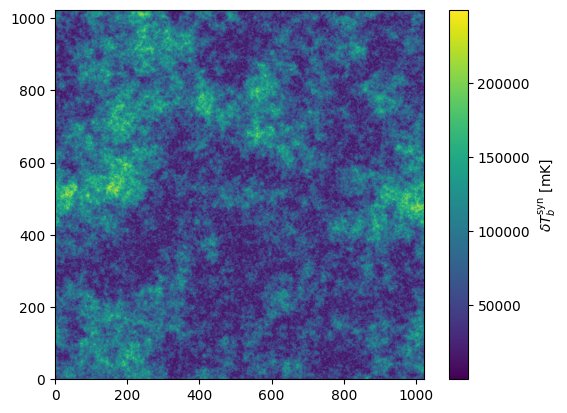

(None, None)

<Figure size 640x480 with 0 Axes>

In [26]:
L_box = 2048 * u.Mpc
N_pix = 1024
random_seed = 918

# define redshift
z = 9.5

# define the corresponding observed frequency
freq = t2c.z_to_nu(z=z) * u.MHz

# galactic foreground syncrotron emeission model
dT = t2c.galactic_synch_fg(z=z, ncells=N_pix, boxsize=L_box.value, rseed=random_seed) * u.mK

plt.imshow(dT.value, origin='lower')
plt.colorbar(label=r'$\delta T^\mathrm{syn}_b$ [%s]' %dT.unit)
plt.show(), plt.clf()

### Prepare data for KARABO

In [30]:
# select SKA-Low central location
loc = EarthLocation(lon=116.7644482*u.deg, lat=-26.82472208*u.deg)

# select local time
#t = Time('J2000', scale='utc', location=loc)
t = Time('2021-09-21 14:12:40.1', scale='utc', location=loc) # like in the SDC3a data challenge

# get zenit point at this location
sc = SkyCoord(ra=t.sidereal_time('apparent'), dec=loc.lat)
ra, dec = sc.ra.deg, sc.dec.deg
print(t, ':\t', 'RA = %.3f\tDEC = %.3f' %(ra, dec))

# angular resolution in rad
dthet = L_box / ((1+z)*cosmo.angular_diameter_distance(z)*N_pix) * u.rad
print('angular resolution of the input image:', dthet.to('arcsec'))

# field of view
FoV = (dthet*N_pix).to('deg')
print('FoV: %.3f %s' %(FoV.value, FoV.unit))

# pixel area
pixel_area = (np.pi*dthet*dthet/(4*np.log(2))).to('sr')
print('Solid angle (pixel area):', pixel_area)

2021-09-21 14:12:40.100 :	 RA = 330.605	DEC = -26.825
angular resolution of the input image: 43.3156299186435 arcsec
FoV: 12.321 deg
Solid angle (pixel area): 4.99693181079223e-08 sr


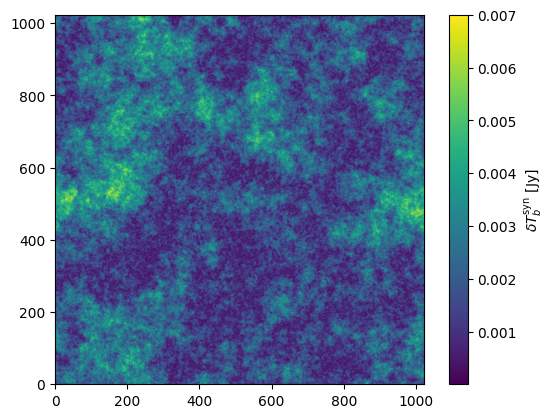

(None, None)

<Figure size 640x480 with 0 Axes>

In [31]:
# equivalence to convert temperature (mK) to brightness (Jy), see: https://science.nrao.edu/facilities/vla/proposing/TBconv
equiv_jy2k = u.brightness_temperature(frequency=freq, beam_area=pixel_area)

# sky model in Jy units
dT_jy = dT.to('Jy', equivalencies=equiv_jy2k)

plt.imshow(dT_jy.value, origin='lower')
plt.colorbar(label=r'$\delta T^\mathrm{syn}_b$ [%s]' %dT_jy.unit)
plt.show(), plt.clf()

## __Testing the galactic_synch_fg_custom function and using Parseval's theorem to find the power spectrum of a point source.__

In [3]:
def galactic_synch_fg_custom(z, ncells, boxsize, rseed=False):
    """
    Simulated synchrotron emission. Simplified because of removed noise.
    """
    if(isinstance(z, float)):
        z = np.array([z])
    else:
        z = np.array(z, copy=False)

    gf_data = np.zeros((ncells, ncells, z.size))

    if(rseed): 
        np.random.seed(rseed)
	
    X  = np.random.normal(size=(ncells, ncells))
    Y  = np.random.normal(size=(ncells, ncells))
    nu_s,A150,beta_,a_syn,Da_syn = 150,513,2.34,2.8,0.1
	
    for i in range(0, z.size):
        nu = t2c.cosmo.z_to_nu(z[i])
        U_cb  = (np.mgrid[-ncells/2:ncells/2,-ncells/2:ncells/2]+0.5)*t2c.cosmo.z_to_cdist(z[i])/boxsize
        l_cb  = 2*np.pi*np.sqrt(U_cb[0,:,:]**2+U_cb[1,:,:]**2)
        C_syn = A150
        solid_angle = boxsize**2/t2c.cosmo.z_to_cdist(z[i])**2
        AA = np.sqrt(solid_angle*C_syn/2)
        T_four = AA*(X+Y*1j) * np.sqrt(2)
        T_real = np.abs(np.fft.ifft2(T_four))   #in Jansky
        gf_data[..., i] = t2c.telescope_functions.jansky_2_kelvin(T_real*1e6, z[i], boxsize=boxsize, ncells=ncells)
        #gf_data[..., i] = T_real

    return gf_data.squeeze()

### __A point source has a flat power spectrum since it is approximately a delta function.__ 
However, if one uses a flat power spectrum in the galactic_synch_fg_custom, the output is a white noise.
One idea to generate a point source from a flat power spectrum is to compute the fft of an image and set the phases
of the complex numbers to zero. This way, all the power should be concentrated to a single point in the image.
This is done below. Unfortunately, the final image has a lot of residual value in other pixels, so I think it is not worth it.

### __Down below is a proof-of-concept 1D case.__

Text(0.5, 1.0, 'Real space signal from the phase-removed FFT')

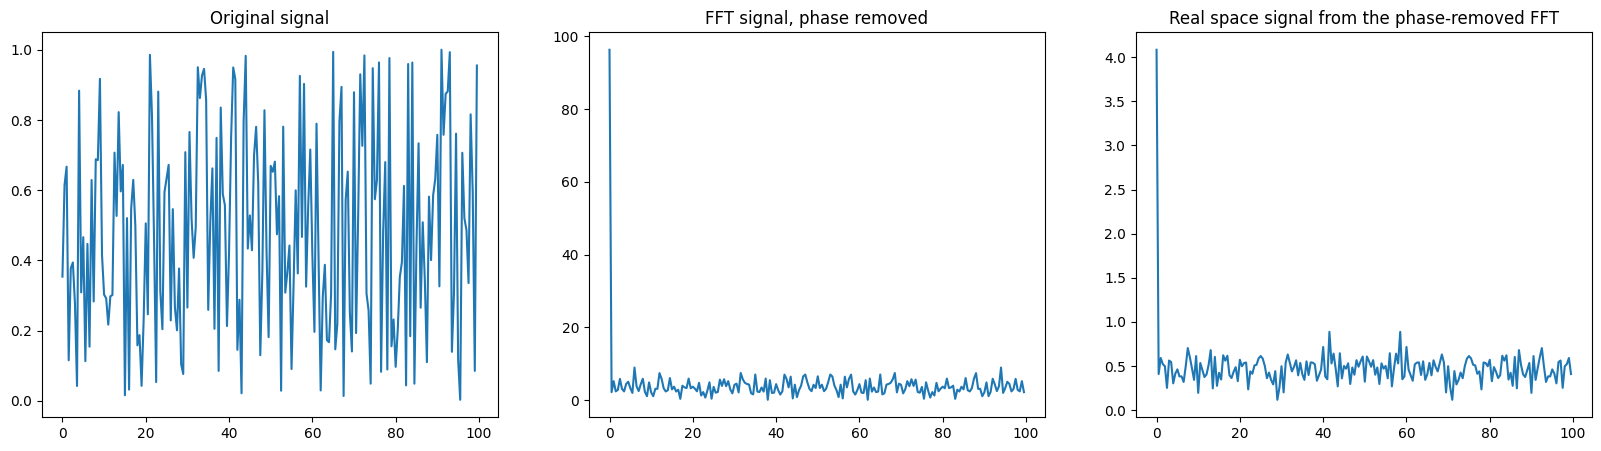

In [67]:
z = np.random.rand(200)
x = np.arange(0, 100,0.5)

z_fft = np.fft.fft(z)

fig, axs = plt.subplots(1,3, figsize=(20, 5))

axs[0].plot(x, z)
axs[0].set_title('Original signal')

axs[1].plot(x, z_fft*np.exp(-1j*np.angle(z_fft)))
axs[1].set_title('FFT signal, phase removed')

axs[2].plot(x, np.fft.ifft(z_fft*np.exp(-1j*np.angle(z_fft))))
axs[2].set_title('Real space signal from the phase-removed FFT')

### __This is now the computation on a white noise image generated by a flat power spectrum.__

The method generates a point source that has a high enoguh value to distinguish it from the other pixels, but the other pixels also
have large values (1e6 to 1e7), making this method not ideal.

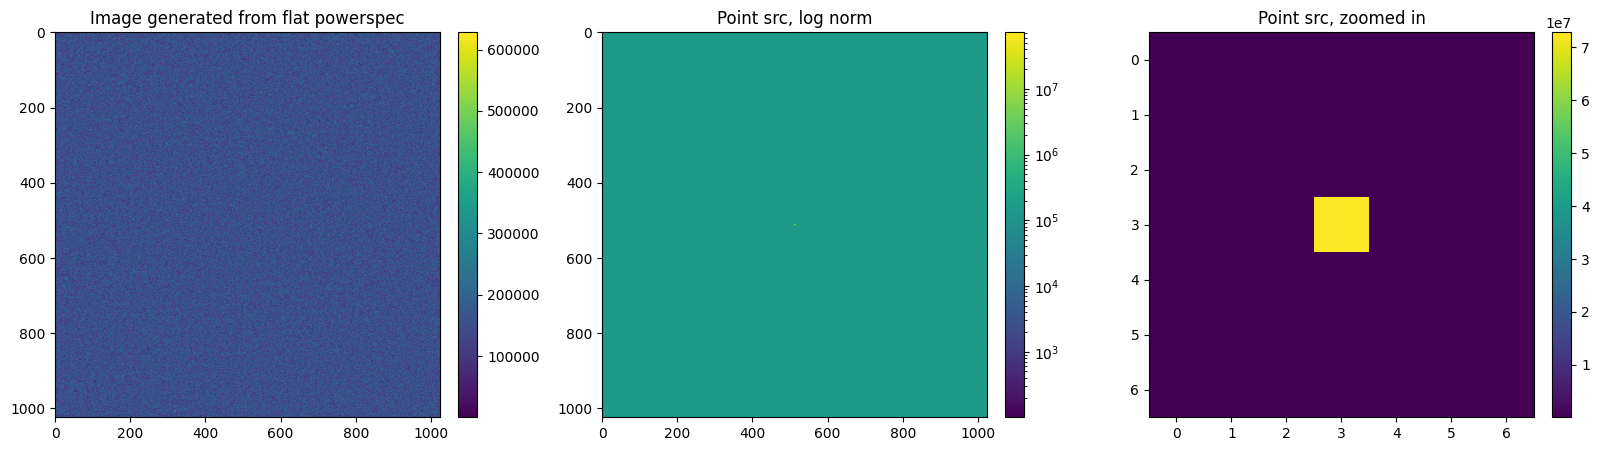

In [5]:
z= 7.554
L_box = 2048 * u.Mpc
N_pix = 1024
random_seed = 918

dT = galactic_synch_fg_custom(z=z, ncells=N_pix, boxsize=L_box.value, rseed=random_seed)

real_space = dT
fft = np.fft.fft2(real_space)
fft_src = fft*np.exp(-1j*np.angle(fft))
real_space_src = np.fft.ifft2(fft_src)
real_space_src_centered = np.fft.fftshift(real_space_src)


fig, axs = plt.subplots(1, 3, figsize=(20, 5))
im0 = axs[0].imshow(dT)
axs[0].set_title('Image generated from flat powerspec')
plt.colorbar(im0, fraction=0.046, pad=0.04)

im1 = axs[1].imshow(real_space_src_centered.real, norm = LogNorm())
axs[1].set_title('Point src, log norm')
plt.colorbar(im1, fraction=0.046, pad=0.04)

im2 = axs[2].imshow(real_space_src_centered.real[509:516, 509:516])
axs[2].set_title('Point src, zoomed in')
plt.colorbar(im2, fraction=0.046, pad=0.04)

### __Another method is to use Parseval's theorem.__

Parseval's theorem states that: $$\frac{1}{N}\int_{-\infty}^{+\infty}\,|F(\omega)|^2 d\omega = \int_{-\infty}^{+\infty}\,|f(t)|^2 dt$$

That way a sum of the square of the pixels of the generated white noise image can tell you the sum of the square of the pixels in Fourier space. Since the power spectrum is flat, all the pixels will have the same value, and you can recover A150.

In [64]:
def galactic_synch_fg_custom(z, ncells, boxsize, rseed=False):
    if(isinstance(z, float)):
        z = np.array([z])
    else:
        z = np.array(z, copy=False)

    gf_data = np.zeros((ncells, ncells, z.size))

    if(rseed): 
        np.random.seed(rseed)
	
    X  = np.random.normal(size=(ncells, ncells))
    Y  = np.random.normal(size=(ncells, ncells))

    nu_s,A150,beta_,a_syn,Da_syn = 150,513,2.34,2.8,0.1
	
    for i in range(0, z.size):
        nu = t2c.cosmo.z_to_nu(z[i])
        U_cb  = (np.mgrid[-ncells/2:ncells/2,-ncells/2:ncells/2]+0.5)*t2c.cosmo.z_to_cdist(z[i])/boxsize
        l_cb  = 2*np.pi*np.sqrt(U_cb[0,:,:]**2+U_cb[1,:,:]**2)
        #C_syn = A150*(1000/l_cb)**beta_
        C_syn = A150
        solid_angle = boxsize**2/t2c.cosmo.z_to_cdist(z[i])**2
        AA = np.sqrt(solid_angle*C_syn/2)
        T_four = AA*(X+Y*1j) * np.sqrt(2)
        T_real = np.abs(np.fft.ifft2(T_four))   #in Jansky
        #gf_data[..., i] = t2c.telescope_functions.jansky_2_kelvin(T_real*1e6, z[i], boxsize=boxsize, ncells=ncells)
        gf_data[..., i] = T_real

    return gf_data.squeeze(), T_four

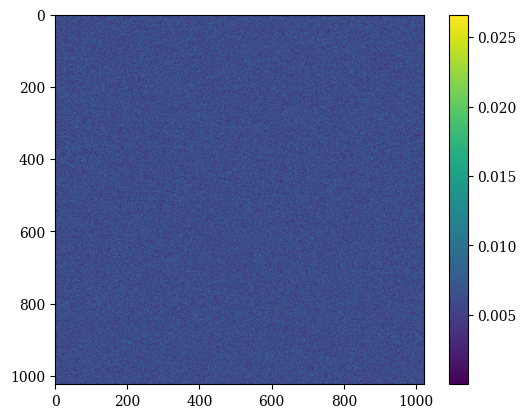

In [65]:
dT, fft = galactic_synch_fg_custom(z=7.554, ncells=1024, boxsize=2048, rseed=913)
plt.imshow(dT)
plt.colorbar()

### __Down below is proof that Parseva's theorem works.__

The integral (in this case the sum) over all pixels yields the correct value. The integral can also be taken over the Fourier transformed image- the result is the same. The N in this case is the number of pixels, which is $1024^2$

In [6]:
dT, fft = galactic_synch_fg_custom(z=7.554, ncells=1024, boxsize=6466, rseed=913)

print("integral(dT^2): ", np.sum(dT**2))
print("1/N integral(|fft|^2): ", np.sum(np.abs(fft)**2) / (1024**2))
print("1/N integral(|fft(dT)|^2): ", np.sum(np.abs(np.fft.fft2(dT))**2) / (1024**2))

integral(dT^2):  513.2332221210856
1/N integral(|fft|^2):  513.2332221210851
1/N integral(|fft(dT)|^2):  513.2332221210858


Flat power spectrum constant:  256.70260329396456
1.9984214940451341
Solid angle:  0.2500114058600513


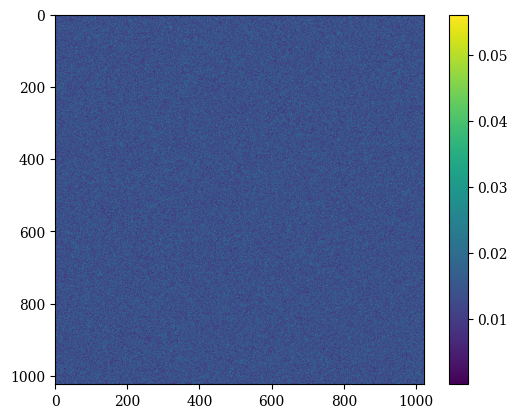

In [18]:
boxsize = 4572
z = 7.554
ncells = 1024
dT, fft = galactic_synch_fg_custom(z=z, ncells=ncells, boxsize=boxsize, rseed=19)

# This is to be used if the output is in mK and not in Jy
#dT = t2c.telescope_functions.kelvin_2_jansky(dT/1e6, 7.554, boxsize=2048, ncells=1024)

plt.imshow(dT)
plt.colorbar()

# Step 1: Compute the 2D Fourier Transform of the image
dT_fft = np.fft.fft2(dT)

# Step 2: Calculate the Power Spectrum
powerspec = np.abs(dT_fft)**2

# Step 3: Estimate the Flat Power Spectrum Constant
flat_power_spectrum_constant = np.mean(powerspec)

print("Flat power spectrum constant: ", flat_power_spectrum_constant)
print(513 / flat_power_spectrum_constant)
print("Solid angle: ", boxsize**2/t2c.cosmo.z_to_cdist(z)**2)

In [12]:
print("Ratio between A150 used to generate the image and the recovered flat power spectrum constant: ", 513 / flat_power_spectrum_constant)

Ratio between A150 used to generate the image and the recovered flat power spectrum constant:  9.95954804410467


In [15]:
t2c.cosmo.z_to_cdist(7.554) / 2

4571.895708384284

In [15]:
image = np.zeros((1024, 1024))
image[512, 512] = np.sqrt(513)

image_fft = np.fft.fft2(image)

recovered_powerspec = np.mean(np.abs(image_fft)**2)

print("Recovered powerspectrum: ", recovered_powerspec)
print("Original image power: ", np.sum(image**2))

#------------------------------------------------
X  = np.random.normal(size=(1024, 1024))
Y  = np.random.normal(size=(1024, 1024))
boxsize = 2048
C_syn = 513
z = 7.554216867469879

solid_angle = boxsize**2 / t2c.cosmo.z_to_cdist(z)**2
print('Solid angle: ', solid_angle)
AA = np.sqrt(solid_angle * C_syn / 2)
T_four = AA*(X+Y*1j) * np.sqrt(2)
T_real = np.abs(np.fft.ifft2(T_four))

print("T_four power:", np.sum(np.abs(T_four)**2 / 1024**2))
print("T_real power:", np.sum(T_real**2))

T_real_fft = np.fft.fft2(T_real)
print("T_real_fft power:", np.sum(np.abs(T_real_fft)**2 / 1024**2))

Recovered powerspectrum:  513.0
Original image power:  513.0
Solid angle:  0.05016496419439696
T_four power: 51.46219424506576
T_real power: 51.462194245065774
T_real_fft power: 51.46219424506577


In [22]:
X  = np.random.normal(size=(1024, 1024))
Y  = np.random.normal(size=(1024, 1024))
boxsize = 2048
C_syn = 513
z = 7.554216867469879

solid_angle = boxsize**2 / t2c.cosmo.z_to_cdist(z)**2
AA = np.sqrt(solid_angle * C_syn / 2)
T_four = AA*(X+Y*1j) * np.sqrt(2)
T_real = np.abs(np.fft.ifft2(T_four))

print("T_four power:", np.sum(np.abs(T_four)**2) / 1024**2)
print("T_real power:", np.sum(T_real**2))
print("Solid angle: ", solid_angle)

T_four power: 51.575538471159966
T_real power: 51.57553847115996
Solid angle:  0.05016496419439696


In [23]:
image = np.zeros((1024, 1024))
image[512, 512] = np.sqrt(51.58)

image_fft = np.fft.fft2(image)

recovered_powerspec = np.mean(np.abs(image_fft)**2)

print("Recovered powerspectrum: ", recovered_powerspec)
print("Original image power: ", np.sum(image**2))


Recovered powerspectrum:  51.57999999999995
Original image power:  51.58


In [ ]:
bl_mag = np.linalg.norm(bls_skalow, axis = 1)
combined_array = np.hstack((bls_skalow[:], bl_mag[:,None], visls_skalow[:,None]))
sorted_combined_array = combined_array[np.argsort(combined_array[:,2])]

blcoord_sorted = sorted_combined_array[:,0:2].real
blmag_sorted = sorted_combined_array[:,2].real
vis_sorted = sorted_combined_array[:,-1]

blmag_sorted_transformed = np.log10(blmag_sorted)
# *****************************************************************************************
bins = np.linspace(np.min(blmag_sorted_transformed), np.max(blmag_sorted_transformed), 30)
bin_indices = np.digitize(blmag_sorted_transformed, bins) - 1

hist, _ = np.histogram(bin_indices, bins = np.arange(0, 31))
cum_counts = np.cumsum(hist)

bin_blcoords = np.split(blcoord_sorted, cum_counts[:-1])
bin_vis = np.split(vis_sorted, cum_counts[:-1])
bin_blmags = np.split(blmag_sorted, cum_counts[:-1])

print(hist)

In [5]:
N_ant = len(skalow_layout)
N_B = N_ant * (N_ant - 1) // 2
idx_i, idx_j = np.triu_indices(N_B, k=1)

baseline_coord = cp.empty((N_B, skalow_layout.shape[1]))

for i in tqdm(range(N_B)):
    aa, bb = idx_i[i], idx_j[i]
    uv = (skalow_layout[bb] - skalow_layout[aa]) / lam

30
